In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import cmocean.cm as cm
from shapely.geometry import Point, MultiPolygon
import shapely
from matplotlib.patches import Polygon as MatplotlibPolygon
import geopandas as gpd
# from scipy.optimize import curve_fit
# from scipy import signal
import matplotlib.patches as patches

# from matplotlib.animation import FuncAnimation
# import matplotlib.animation as animation

from salishsea_tools import viz_tools

# Goal
Turn model results for 2019 into something that shows the spatial and temporal distributions of scrubber washwater in the Salish Sea. We were going to do 3 dyes with different half-lives, so I will probably have this notebook as the master notebook and then make two others for the different dyes.

Our parameter of interest is washwater concentration. We can use the concentrations reported in Hermansson et al. and the initial report (cite) to set contours of washwater concentration.

In [2]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
tmask = 1 - mesh.tmask[0]
volume = ((1-tmask) * mesh.e3t_0[0] * mesh.e1t[0] * mesh.e2t[0]).rename({'z':'depth'})

In [3]:
## read in the input washwater file
ww_in = xr.open_dataset('/ocean/cdonaldson/scrubbers/yearly_obs/scrubber_1d_obs_tempsalcalc_20190101_20191231.nc')

In [4]:
## read in the year of results
ww_out = xr.open_dataset('/ocean/cdonaldson/scrubbers/calcs/SalishSea_1d_20200101_20201231_scrb_T.nc')

## read in the averaged results
ww_seas_mean = xr.open_dataset('/ocean/cdonaldson/scrubbers/calcs/SalishSea_1d_20200101_20201231_scrb_T_seas.nc')
ww_mon_mean = xr.open_dataset('/ocean/cdonaldson/scrubbers/calcs/SalishSea_1d_20200101_20201231_scrb_T_mon.nc')

filesave_tag = 'dep8m_y2020'

## Concentrations of Interest

- Fertilisation of sea urchin eggs impacted @ 1: 1,000,000 (Environmental Impacts... Jalken et al., 2024)
- Early development of polycheats, mussels, and crustaceans impacted @ 1: 100,000 (Environmental Impacts... Jalken et al., 2024)
- HC5 = 0.0003% (Impact Assessment... Hermansson et al., 2025)
- HC5 lower limit = 0.00001% (Impact Assessment... Hermansson et al., 2025)
- HC5 upper limit = 0.009% (Impact Assessment... Hermansson et al., 2025)
- (HC50 = 0.6%; lower limit = 0.02%, upper limit = 1.4%) (Impact Assessment... Hermansson et al., 2025)

In [5]:
custom_colors = ['#ff595e', '#ffca3a', '#8ac926', '#1982c4', '#6a4c93']
# custom_colors = ['#E0E0E2', '#ff595e', '#ffca3a', '#8ac926', '#1982c4', '#6a4c93']

In [6]:
impact_urchins = 1/1000000
impact_devel = 1/100000
HC5 = 0.0003/100
HC5_low = 0.00001/100
HC5_high = 0.009/100
HC50_low = 0.02/100
HC50 = 0.6/100
HC50_high = 1.4/100

In [7]:
lim_dict = {
    'impact_urchins': impact_urchins,
    'impact_devel': impact_devel,
    'HC5': HC5,
    'HC5_low': HC5_low,
    'HC5_high': HC5_high,
    'HC50_low': HC50_low,
    'HC50': HC50,
    'HC50_high': HC50_high
}

lim_dict = {k: v for k, v in sorted(lim_dict.items(), key=lambda item: item[1])}
lim_dict

{'HC5_low': 1.0000000000000001e-07,
 'impact_urchins': 1e-06,
 'HC5': 2.9999999999999997e-06,
 'impact_devel': 1e-05,
 'HC5_high': 8.999999999999999e-05,
 'HC50_low': 0.0002,
 'HC50': 0.006,
 'HC50_high': 0.013999999999999999}

In [8]:
month_list = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

## Spatial Visualizations

### Functions

In [9]:
def plot_conc_seasonal(dep_idx, season, axs, variable, cbar, cmap, fig, vmax1):
    washwater = np.ma.masked_array(ww_seas_mean.sel(season=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    colours = axs.pcolormesh(washwater, cmap=cmap, vmin=0, vmax=vmax1)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ' + r'[m$^3$m$^{-3}$]'), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    # axs.set_ylabel('Grid Y')
    # axs.set_xlabel('Grid X')
    # axs.set_title('idep={}\n{}   '.format(dep_idx, season))
    axs.set_title('{:.3g} m\n{}   '.format(float(ww_out.deptht[dep_idx]), season))
    viz_tools.set_aspect(axs);
    # axs.legend()

In [10]:
def plot_conc_monthly(dep_idx, season, axs, variable, cbar, legend, cmap, fig, vmax1):
    washwater = np.ma.masked_array(ww_mon_mean.isel(month=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    colours = axs.pcolormesh(washwater, cmap=cmap, vmin=0, vmax=vmax1)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    # axs.set_ylabel('Grid Y')
    # axs.set_xlabel('Grid X')
    # axs.set_title('idep={}\n{}   '.format(dep_idx, month_list[season]))
    axs.set_title('{:.3g} m\n{}   '.format(float(ww_out.deptht[dep_idx]), month_list[season]))
    viz_tools.set_aspect(axs);
    if legend == True:
        axs.legend()

In [11]:
def plot_bool_seasonal(dep_idx, season, axs, variable, limit, cbar):
    washwater = np.ma.masked_array(ww_seas_mean.sel(season=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    bool = washwater >= limit
    colours = axs.pcolormesh(bool, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=r'[] washwater >= {:.2g}'.format(limit, 2), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    # axs.set_ylabel('Grid Y')
    # axs.set_xlabel('Grid X')
    # axs.set_title('idep={}\n{}   '.format(dep_idx, season))
    axs.set_title('{:.3g} m\n{}   '.format(float(ww_out.deptht[dep_idx]), season))
    viz_tools.set_aspect(axs);
    axs.legend()

In [12]:
def plot_conc_daily(dep_idx, time_idx, axs, variable, cbar):
    washwater = np.ma.masked_array(ww_out.isel(time_counter=time_idx).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    colours = axs.pcolormesh(washwater, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ' + r'[m$^3$m$^{-3}$]'), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    # axs.set_ylabel('Grid Y')
    # axs.set_xlabel('Grid X')
    axs.set_title('idep={},itime={}\n'.format(dep_idx, time_idx))
    viz_tools.set_aspect(axs);
    axs.legend()

In [13]:
def plot_bool_daily(dep_idx, time_idx, axs, variable, limit, cbar):
    washwater = np.ma.masked_array(ww_out.isel(time_counter=time_idx).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    bool = washwater >= HC5
    colours = axs.pcolormesh(bool, cmap=cmap)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=r'[] washwater >= {:.2g}'.format(limit, 2), location='right')
    if cbar == False:
        cb = fig.colorbar(colours, ax=axs, location='right')
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    axs.set_ylabel('Grid Y')
    axs.set_xlabel('Grid X')
    axs.set_title('idep={},itime={}\n'.format(dep_idx, time_idx))
    viz_tools.set_aspect(axs);
    axs.legend()

In [14]:
def create_thresh_arr(ww_arr):
    under_thresh_bool = np.ma.masked_array(ww_arr, mask=tmask) < HC5_low
    HC5_low_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= HC5_low, np.ma.masked_array(ww_arr, mask=tmask) < impact_urchins)
    impact_urchins_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= impact_urchins, np.ma.masked_array(ww_arr, mask=tmask) < HC5)
    HC5_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= HC5, np.ma.masked_array(ww_arr, mask=tmask) < impact_devel)
    impact_devel_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= impact_devel, np.ma.masked_array(ww_arr, mask=tmask) < HC5_high)
    HC5_high_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= HC5_high, np.ma.masked_array(ww_arr, mask=tmask) < HC50_low)

    thresh_arr = np.zeros(ww_arr.shape)

    thresh_arr[under_thresh_bool] = 1
    thresh_arr[HC5_low_bool] = 2
    thresh_arr[impact_urchins_bool] = 3
    thresh_arr[HC5_bool] = 4
    thresh_arr[impact_devel_bool] = 5
    thresh_arr[HC5_high_bool] = 6
    thresh_arr = np.ma.masked_array(thresh_arr, mask=tmask)

    return thresh_arr

In [15]:
# def plot_thresh_seasonal(thresh_arr, dep_idx, season, axs, variable, cbar, legend, levels):

#     cmap = mcolors.ListedColormap(custom_colors)
#     norm = mcolors.BoundaryNorm(levels, cmap.N)

#     washwater = np.ma.masked_array(thresh_arr[dep_idx], mask=tmask[dep_idx])
#     maxm = np.nanmax(washwater)
#     # colours = axs.contourf(washwater, levels=levels, cmap=cmap, norm=norm)
#     colours = axs.pcolormesh(washwater, cmap=cmap, norm=norm)
#     if cbar == True:
#         cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ' + r'[m$^3$m$^{-3}$]'), location='right')
#     else:
#         return [colours, variable]
#     US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
#     patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
#     axs.add_patch(patch)
#     # axs.set_ylabel('Grid Y')
#     # axs.set_xlabel('Grid X')
#     # axs.set_title('Dep idx = {}\nTime idx = {}'.format(dep_idx, season))
#     axs.set_title('{:.3g} m\n{}   '.format(float(ww_out.deptht[dep_idx]), season))
#     viz_tools.set_aspect(axs);
#     if legend == True:
#         axs.legend()

In [16]:
def plot_contours_seasonal(dep_idx, season, axs, variable, cbar, legend, levels):

    cmap = mcolors.ListedColormap(custom_colors)
    norm = mcolors.BoundaryNorm(levels, cmap.N)

    washwater = np.ma.masked_array(ww_seas_mean.sel(season=season).isel(deptht=dep_idx)[variable], mask=tmask[dep_idx])
    maxm = np.nanmax(washwater)
    colours = axs.contourf(washwater, levels=levels, cmap=cmap, norm=norm)
    if cbar == True:
        cb = fig.colorbar(colours, ax=axs, label=('WW Conc. ' + r'[m$^3$m$^{-3}$]'), location='right')
    else:
        return [colours, variable]
    US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
    patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
    axs.add_patch(patch)
    # axs.set_ylabel('Grid Y')
    # axs.set_xlabel('Grid X')
    # axs.set_title('Dep idx = {}\nTime idx = {}'.format(dep_idx, season))
    axs.set_title('{:.3g} m\n{}   '.format(float(ww_out.deptht[dep_idx]), season))
    viz_tools.set_aspect(axs);
    if legend == True:
        axs.legend()

In [17]:
# # test_ww_arr = ww_seas_mean.sel(season='HIGH')[decay_var].stack(flat=['y', 'x']).to_numpy()
# test_ww_arr = ww_seas_mean.sel(season='HIGH')['slow_decay'].to_numpy()
# plt.pcolormesh(np.ma.masked_array(test_ww_arr[8,:,:], mask=tmask[8]))

In [18]:
# vol_arr = volume.to_numpy()
# plt.pcolormesh(vol_arr[8,:,:])

In [19]:
# under_thresh_bool = np.ma.masked_array(test_ww_arr, mask=tmask) < HC5_low
# HC5_low_bool = np.logical_and(np.ma.masked_array(test_ww_arr, mask=tmask) >= HC5_low, np.ma.masked_array(test_ww_arr, mask=tmask) < impact_urchins)
# impact_urchins_bool = np.logical_and(np.ma.masked_array(test_ww_arr, mask=tmask) >= impact_urchins, np.ma.masked_array(test_ww_arr, mask=tmask) < HC5)
# HC5_bool = np.logical_and(np.ma.masked_array(test_ww_arr, mask=tmask) >= HC5, np.ma.masked_array(test_ww_arr, mask=tmask) < impact_devel)
# impact_devel_bool = np.logical_and(np.ma.masked_array(test_ww_arr, mask=tmask) >= impact_devel, np.ma.masked_array(test_ww_arr, mask=tmask) < HC5_high)
# HC5_high_bool = np.logical_and(np.ma.masked_array(test_ww_arr, mask=tmask) >= HC5_high, np.ma.masked_array(test_ww_arr, mask=tmask) < HC50_low)

In [20]:
# bloc1 = np.nansum(vol_arr[under_thresh_bool])/np.nansum(vol_arr)
# bloc2 = np.nansum(vol_arr[HC5_low_bool])/np.nansum(vol_arr)
# bloc3 = np.nansum(vol_arr[impact_urchins_bool])/np.nansum(vol_arr)
# bloc4 = np.nansum(vol_arr[HC5_bool])/np.nansum(vol_arr)
# bloc5 = np.nansum(vol_arr[impact_devel_bool])/np.nansum(vol_arr)
# bloc6 = np.nansum(vol_arr[HC5_high_bool])/np.nansum(vol_arr)

In [21]:
def calc_percentages(ww_arr):
    vol_arr = volume.to_numpy()

    under_thresh_bool = np.ma.masked_array(ww_arr, mask=tmask) < HC5_low
    HC5_low_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= HC5_low, np.ma.masked_array(ww_arr, mask=tmask) < impact_urchins)
    impact_urchins_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= impact_urchins, np.ma.masked_array(ww_arr, mask=tmask) < HC5)
    HC5_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= HC5, np.ma.masked_array(ww_arr, mask=tmask) < impact_devel)
    impact_devel_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= impact_devel, np.ma.masked_array(ww_arr, mask=tmask) < HC5_high)
    HC5_high_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= HC5_high, np.ma.masked_array(ww_arr, mask=tmask) < HC50_low)

    bloc1 = np.nansum(vol_arr[under_thresh_bool])/np.nansum(vol_arr)
    bloc2 = np.nansum(vol_arr[HC5_low_bool])/np.nansum(vol_arr)
    bloc3 = np.nansum(vol_arr[impact_urchins_bool])/np.nansum(vol_arr)
    bloc4 = np.nansum(vol_arr[HC5_bool])/np.nansum(vol_arr)
    bloc5 = np.nansum(vol_arr[impact_devel_bool])/np.nansum(vol_arr)
    bloc6 = np.nansum(vol_arr[HC5_high_bool])/np.nansum(vol_arr)

    return [bloc1, bloc2, bloc3, bloc4, bloc5, bloc6]

In [22]:
def calc_perc_crit(ww_arr, mask):
    vol_arr = volume.to_numpy()

    under_thresh_bool = np.ma.masked_array(ww_arr, mask=mask) < 1
    HC5_low_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=mask) >= 1, np.ma.masked_array(ww_arr, mask=mask) < 2)
    impact_urchins_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=mask) >= 2, np.ma.masked_array(ww_arr, mask=mask) < 3)
    HC5_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=mask) >= 3, np.ma.masked_array(ww_arr, mask=mask) < 4)
    impact_devel_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=mask) >= 4, np.ma.masked_array(ww_arr, mask=mask) < 5)
    HC5_high_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=mask) >= 5, np.ma.masked_array(ww_arr, mask=mask) < 6)

    bloc1 = np.nansum(vol_arr[under_thresh_bool])/np.nansum(vol_arr)
    bloc2 = np.nansum(vol_arr[HC5_low_bool])/np.nansum(vol_arr)
    bloc3 = np.nansum(vol_arr[impact_urchins_bool])/np.nansum(vol_arr)
    bloc4 = np.nansum(vol_arr[HC5_bool])/np.nansum(vol_arr)
    bloc5 = np.nansum(vol_arr[impact_devel_bool])/np.nansum(vol_arr)
    bloc6 = np.nansum(vol_arr[HC5_high_bool])/np.nansum(vol_arr)

    return [bloc1, bloc2, bloc3, bloc4, bloc5, bloc6]

In [23]:
# ww_arr = ww_seas_mean.sel(season='HIGH')[decay_var].to_numpy()
# thresh_arr = np.zeros(ww_arr.shape)
# under_thresh_bool = np.ma.masked_array(ww_arr, mask=tmask) < HC5_low
# HC5_low_bool = np.logical_and(np.ma.masked_array(ww_arr, mask=tmask) >= HC5_low, np.ma.masked_array(ww_arr, mask=tmask) < impact_urchins)
# thresh_arr[under_thresh_bool] = 1
# thresh_arr[HC5_low_bool] = 2
# thresh_arr = np.ma.masked_array(thresh_arr, mask=tmask)
# plt.pcolormesh(thresh_arr[0,:,:])

In [24]:
# def calc_percentages_old(ww_arr):
#     water_bool = ~np.isnan(ww_arr)
#     water_vals = ww_arr[water_bool]
#     water_denom = len(water_vals)

#     under_thresh_bool = water_vals < HC5_low
#     HC5_low_bool = np.logical_and(water_vals >= HC5_low, water_vals < impact_urchins)
#     impact_urchins_bool = np.logical_and(water_vals >= impact_urchins, water_vals < HC5)
#     HC5_bool = np.logical_and(water_vals >= HC5, water_vals < impact_devel)
#     impact_devel_bool = np.logical_and(water_vals >= impact_devel, water_vals < HC5_high)
#     HC5_high_bool = np.logical_and(water_vals >= HC5_high, water_vals < HC50_low)

#     bloc1 = len(water_vals[under_thresh_bool])/water_denom
#     bloc2 = len(water_vals[HC5_low_bool])/water_denom
#     bloc3 = len(water_vals[impact_urchins_bool])/water_denom
#     bloc4 = len(water_vals[HC5_bool])/water_denom
#     bloc5 = len(water_vals[impact_devel_bool])/water_denom
#     bloc6 = len(water_vals[HC5_high_bool])/water_denom

#     return [bloc1, bloc2, bloc3, bloc4, bloc5, bloc6]

In [25]:
def plot_monthly_1depth(decay_var, dep_idx):
    cmap = mpl.colormaps['viridis']
    cmap.set_bad('lightgray')
    cmap.set_under('gray')

    fig, ax1 = plt.subplots(2,7, figsize = (12, 6), sharey=True, sharex=True)

    vmax = 1e-5
    plot_conc_monthly(dep_idx, 0, ax1[0,0], decay_var, False, False, cmap, fig, vmax)
    ax1[0,0].set_ylabel('Grid Y')
    plot_conc_monthly(dep_idx, 1, ax1[0,1], decay_var, False, False, cmap, fig, vmax)
    plot_conc_monthly(dep_idx, 2, ax1[0,2], decay_var, False, False, cmap, fig, vmax)
    plot_conc_monthly(dep_idx, 3, ax1[0,3], decay_var, False, False, cmap, fig, vmax)
    plot_conc_monthly(dep_idx, 4, ax1[0,4], decay_var, False, False, cmap, fig, vmax)
    plot_conc_monthly(dep_idx, 5, ax1[0,5], decay_var, False, False, cmap, fig, vmax)
    plot_conc_seasonal(dep_idx, 'LOW', ax1[0,6], decay_var, True, cmap, fig, vmax)

    plot_conc_monthly(dep_idx, 6, ax1[1,0], decay_var, False, False, cmap, fig, vmax)
    ax1[1,0].set_ylabel('Grid Y')
    plot_conc_monthly(dep_idx, 7, ax1[1,1], decay_var, False, False, cmap, fig, vmax)
    plot_conc_monthly(dep_idx, 8, ax1[1,2], decay_var, False, False, cmap, fig, vmax)
    plot_conc_monthly(dep_idx, 9, ax1[1,3], decay_var, False, False, cmap, fig, vmax)
    ax1[1,3].set_xlabel('Grid X')
    plot_conc_monthly(dep_idx, 10, ax1[1,4], decay_var, False, False, cmap, fig, vmax)
    plot_conc_monthly(dep_idx, 11, ax1[1,5], decay_var, False, False, cmap, fig, vmax)
    plot_conc_seasonal(dep_idx, 'HIGH', ax1[1,6], decay_var, True, cmap, fig, vmax)

    fig.suptitle(decay_var)
    fig.tight_layout(pad=1.2)

### No Decay

In [26]:
decay_var = 'no_decay'

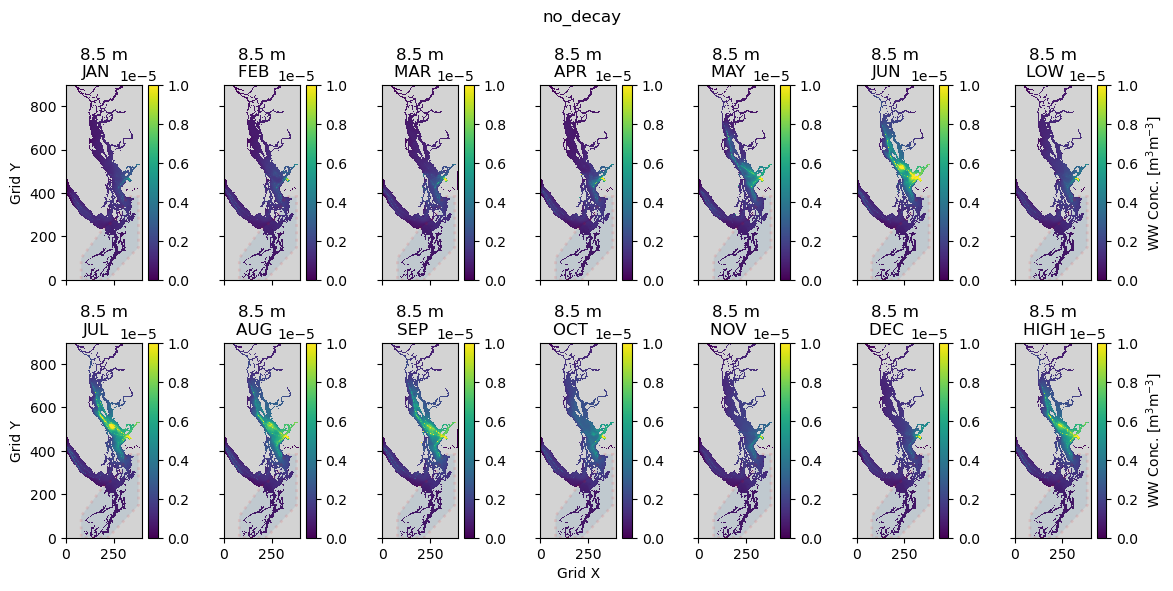

In [27]:
plot_monthly_1depth(decay_var, dep_idx=8)
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/monthly_1depth_{}_{}_{}.png'.format(filesave_tag, decay_var, 8, filesave_tag))

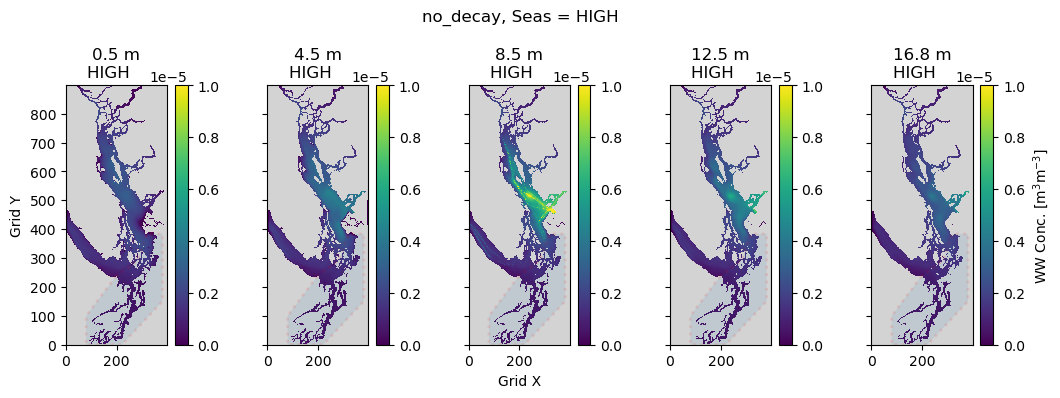

In [28]:
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(1,5, figsize = (11, 4), sharey=True)
season = 'HIGH'
vmax = 1e-5

plot_conc_seasonal(0, season, ax1[0], decay_var, False, cmap, fig, vmax)
plot_conc_seasonal(4, season, ax1[1], decay_var, False, cmap, fig, vmax)
plot_conc_seasonal(8, season, ax1[2], decay_var, False, cmap, fig, vmax)
plot_conc_seasonal(12, season, ax1[3], decay_var, False, cmap, fig, vmax)
plot_conc_seasonal(16, season, ax1[4], decay_var, True, cmap, fig, vmax)
ax1[0].set_ylabel('Grid Y')
ax1[2].set_xlabel('Grid X')

fig.suptitle(decay_var+', Seas = {}'.format(season))
fig.tight_layout(pad=1.2)
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/1season_multdepth_{}_{}.png'.format(filesave_tag, decay_var, filesave_tag))

In [29]:
### KEEP to look at additional threshold values
# cmap = mpl.colormaps['viridis']
# cmap.set_bad('lightgray')
# cmap.set_under('gray')

# fig, ax1 = plt.subplots(1,5, figsize = (11, 4), sharey=True)
# seas = 'HIGH'

# plot_bool_seasonal(0, seas, ax1[0], decay_var, impact_urchins, False)
# plot_bool_seasonal(4, seas, ax1[1], decay_var, impact_urchins, False)
# plot_bool_seasonal(8, seas, ax1[2], decay_var, impact_urchins, False)
# plot_bool_seasonal(12, seas, ax1[3], decay_var, impact_urchins, False)
# plot_bool_seasonal(16, seas, ax1[4], decay_var, impact_urchins, True)
# ax1[0].set_ylabel('Grid Y')
# ax1[2].set_xlabel('Grid X')

# fig.suptitle(decay_var)
# fig.tight_layout(pad=1.2)
# plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/1season_multdepth_bool_{}_{}.png'.format(filesave_tag, decay_var, filesave_tag))

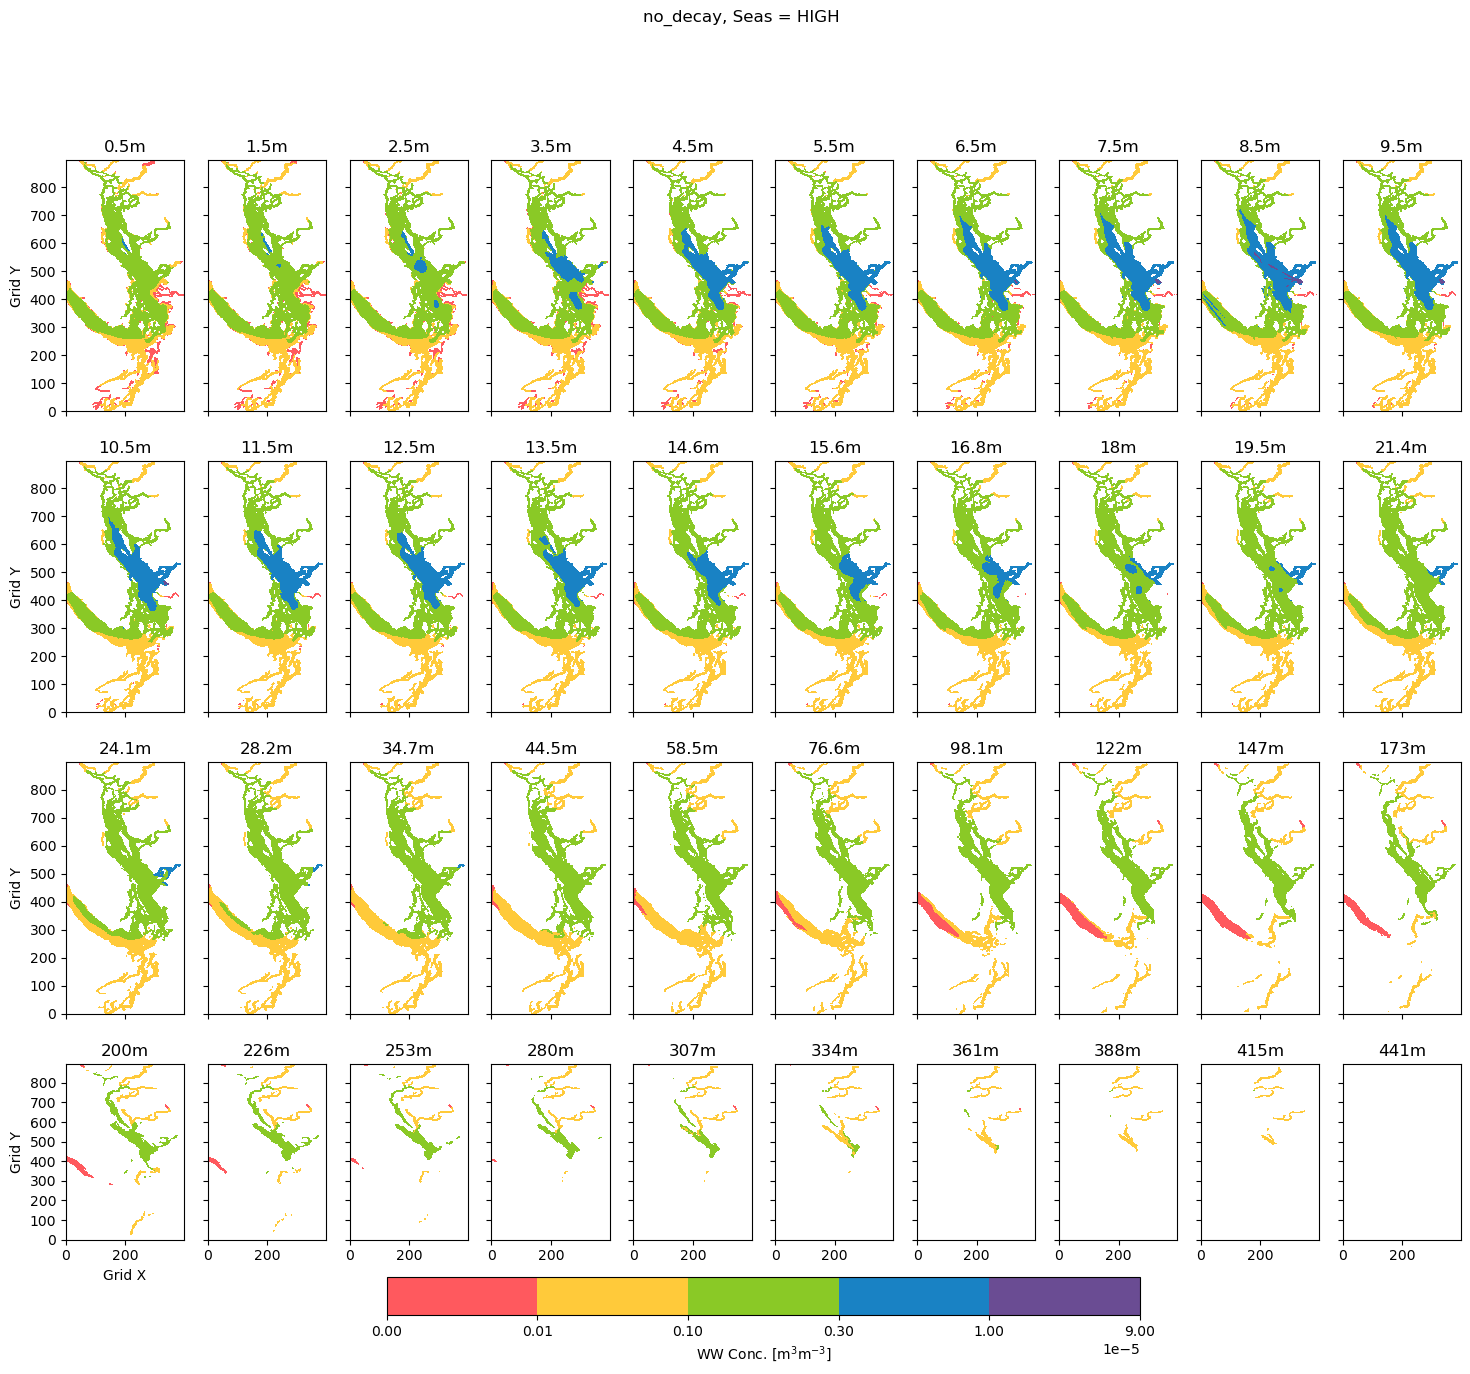

In [30]:
season='HIGH'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

# thresh_arr = create_thresh_arr(ww_seas_mean.sel(season=season)['no_decay'].to_numpy())

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    # vars = plot_thresh_seasonal(thresh_arr, i, season, ax1[y,x], decay_var, False, False, [1,2,3,4,5,6])
    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

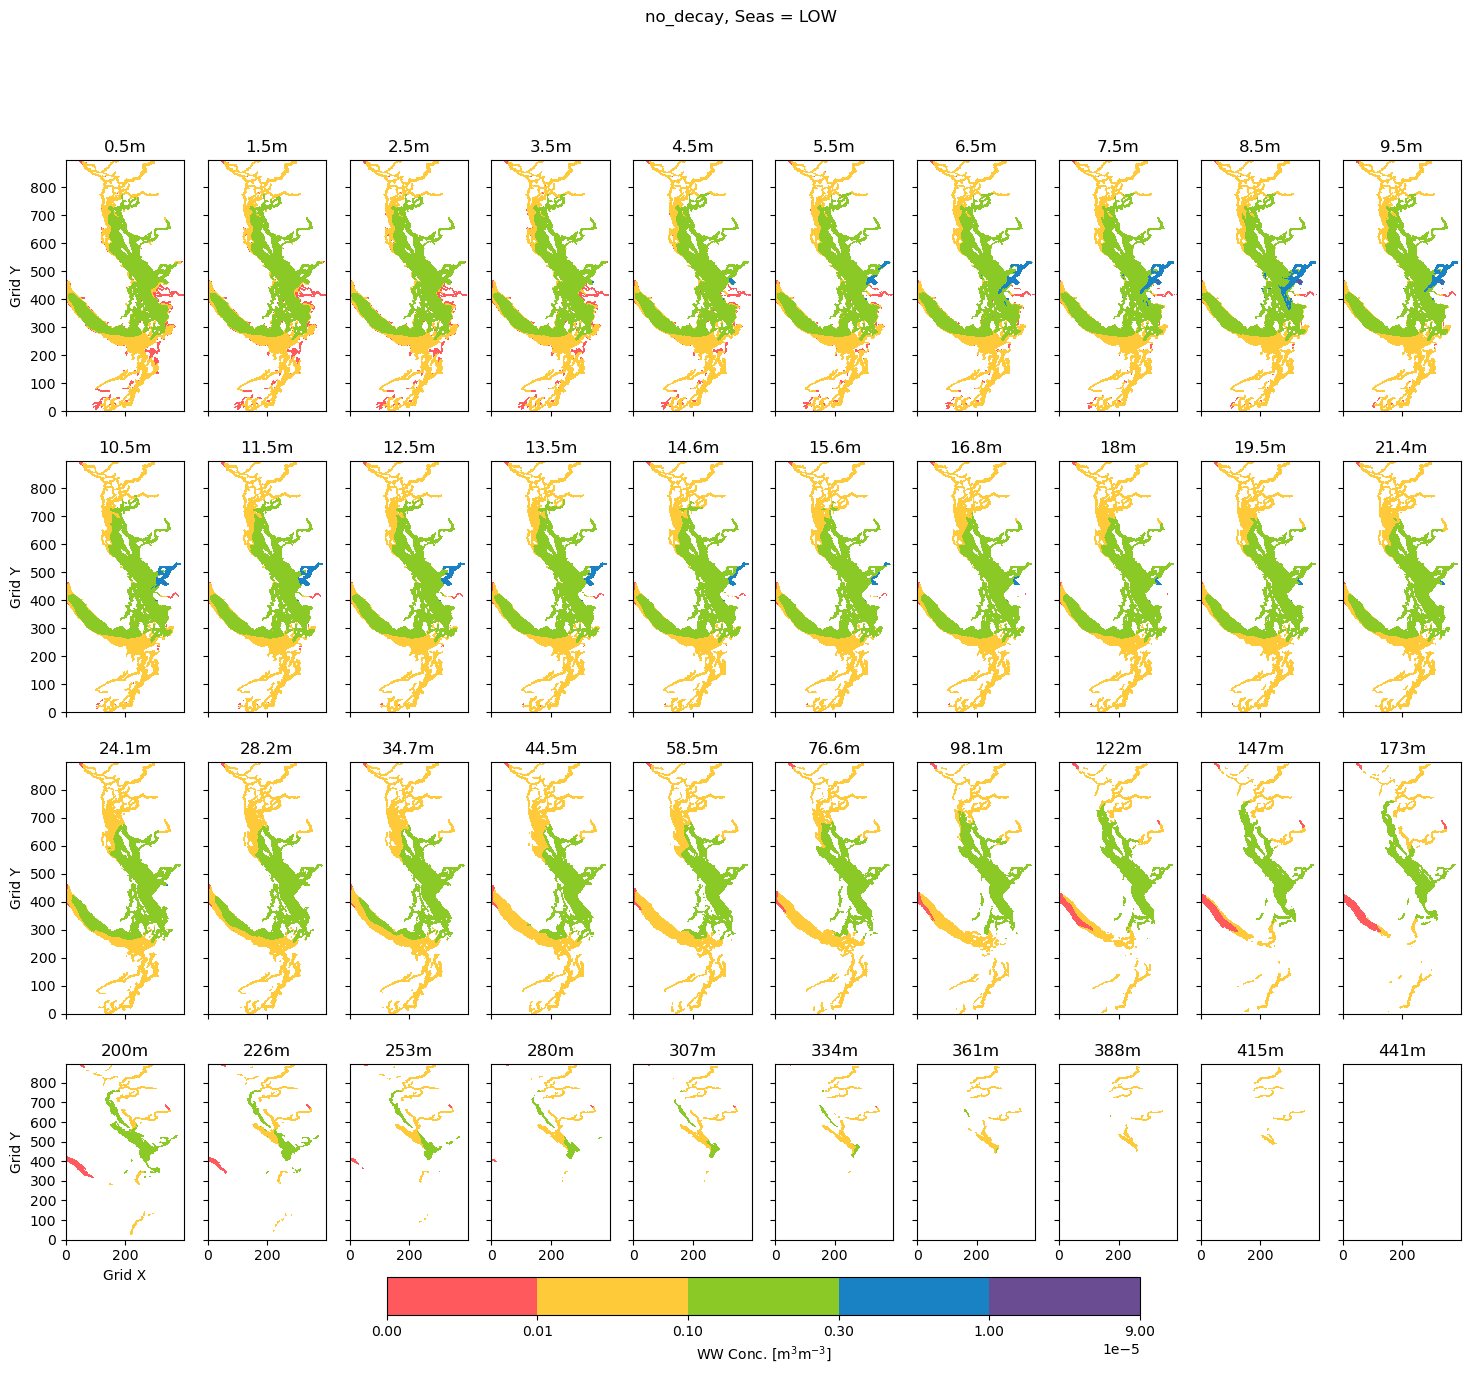

In [31]:
season='LOW'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)
fig.suptitle('Season = LOW')

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

### Slow Decay

In [32]:
decay_var = 'slow_decay'

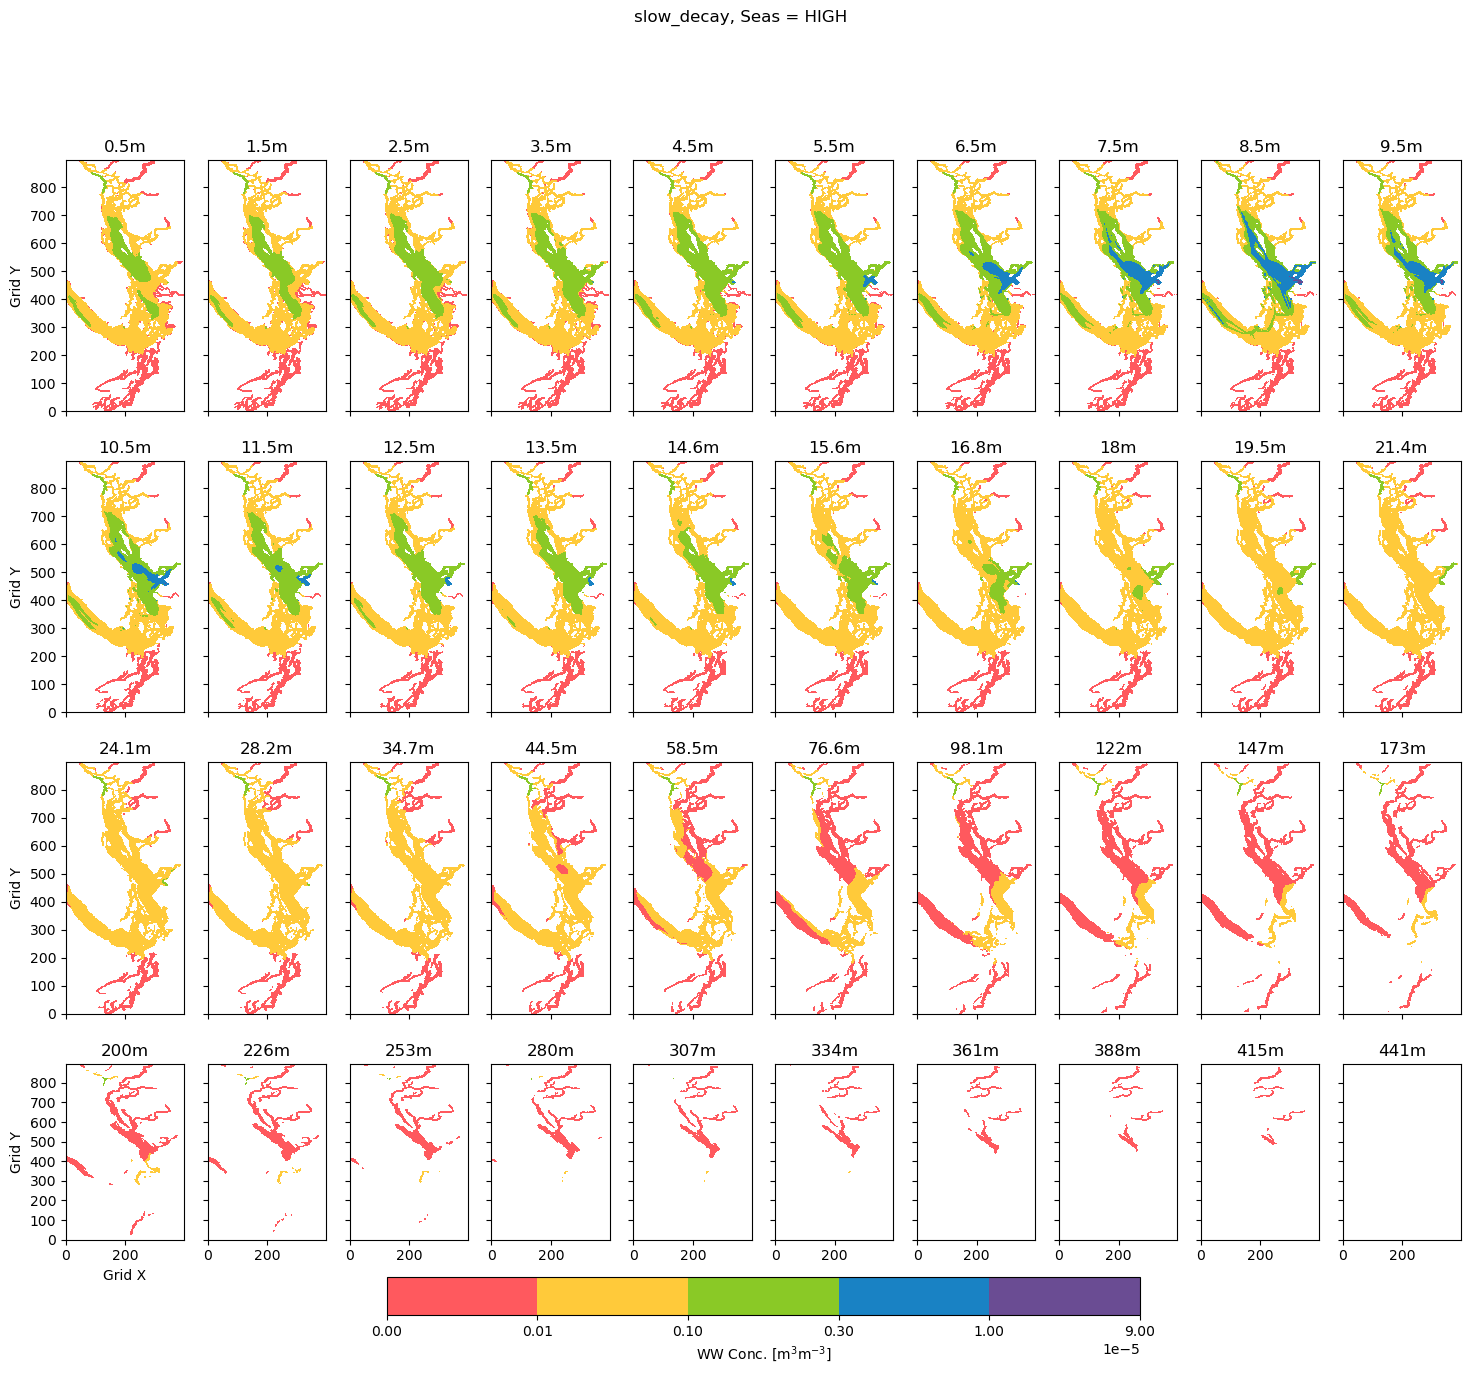

In [33]:
season='HIGH'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

# thresh_arr = create_thresh_arr(ww_seas_mean.sel(season=season)['no_decay'].to_numpy())

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    # vars = plot_thresh_seasonal(thresh_arr, i, season, ax1[y,x], decay_var, False, False, [1,2,3,4,5,6])
    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

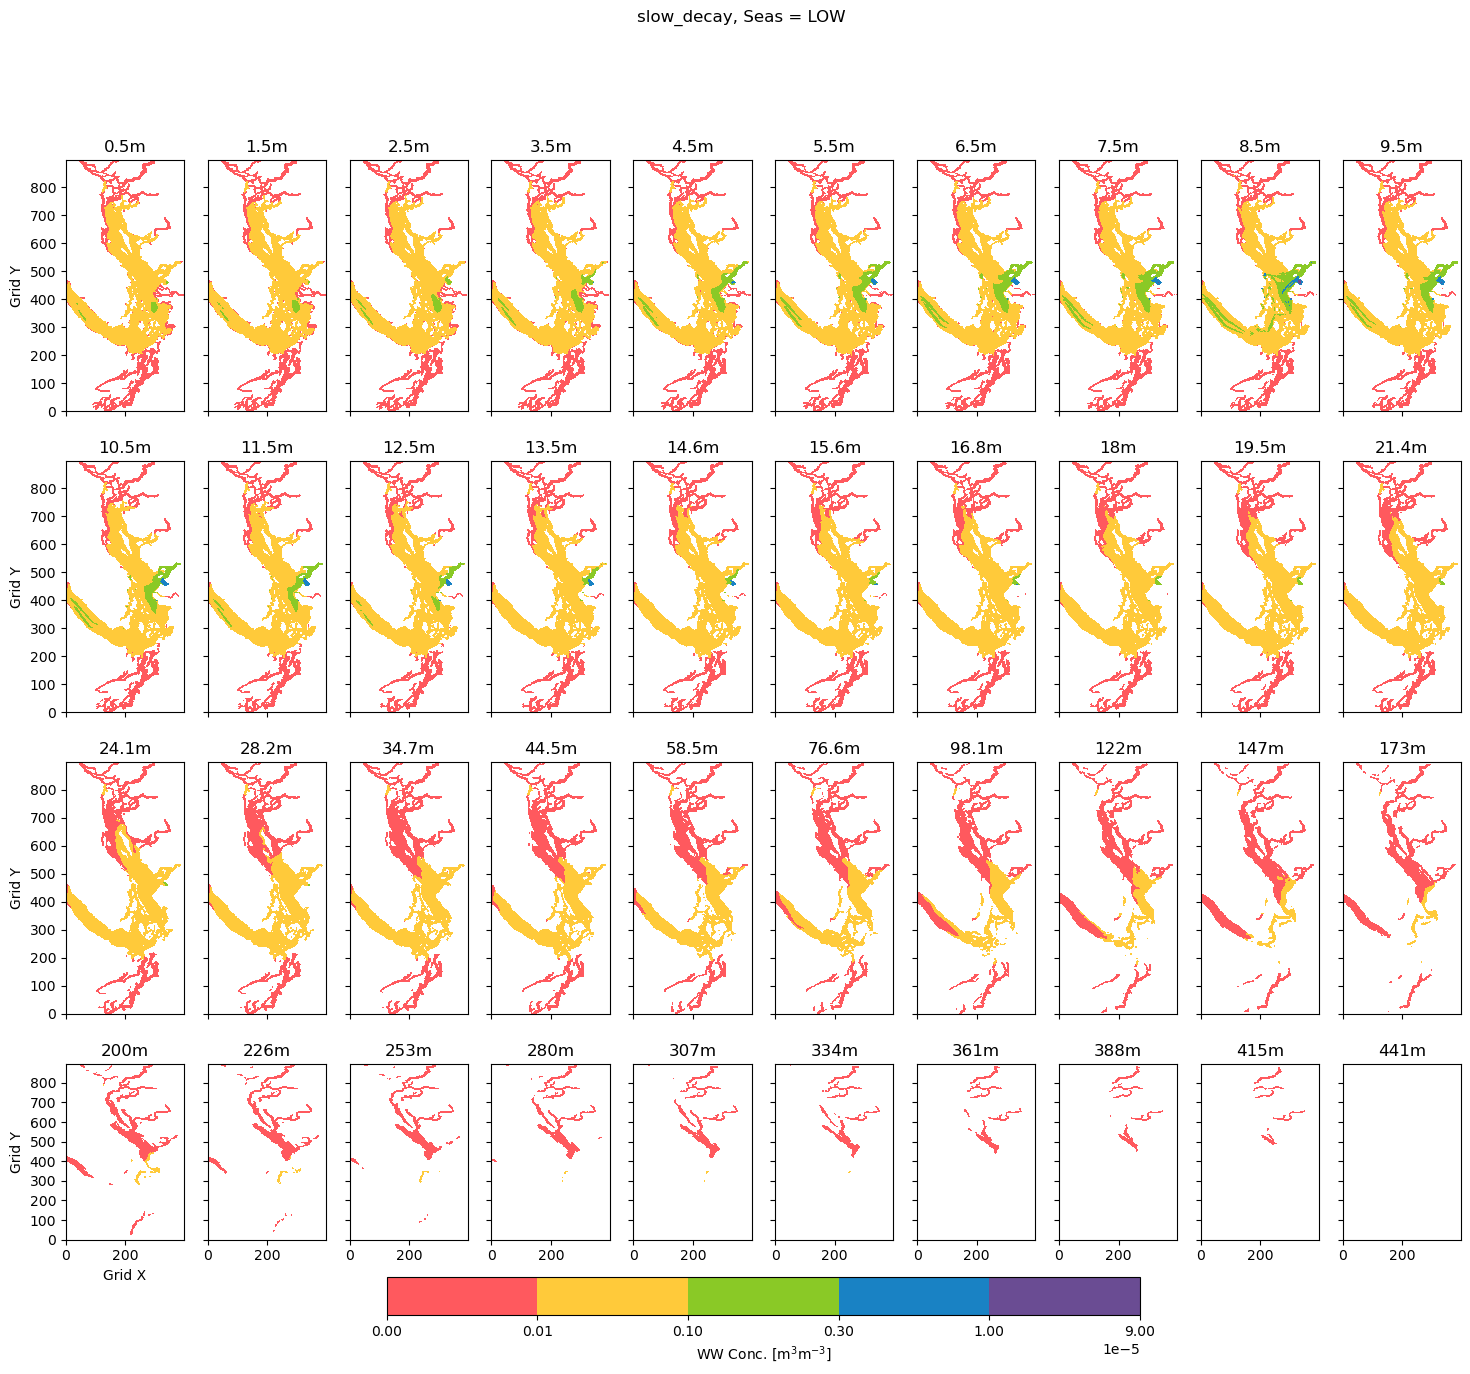

In [34]:
season='LOW'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)
fig.suptitle('Season = LOW')

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

### Medium Decay

In [35]:
decay_var = 'medium_decay'

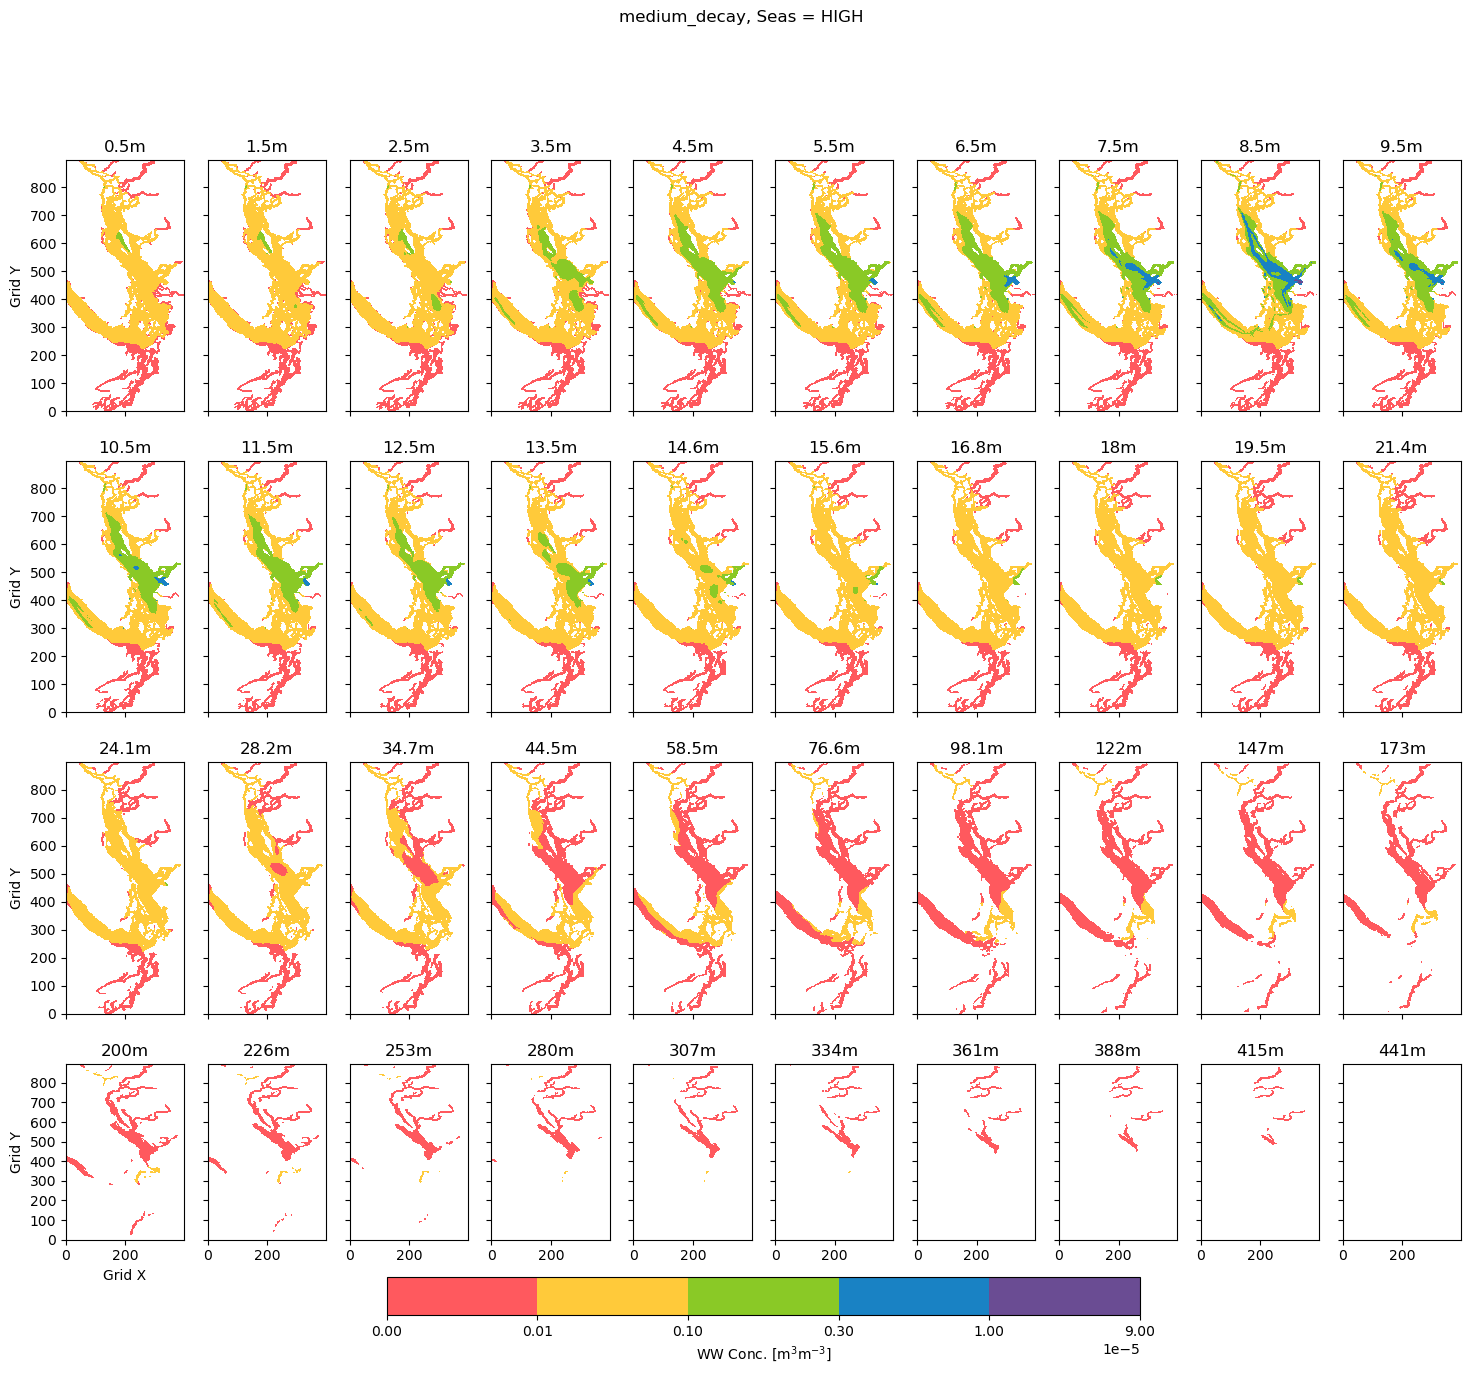

In [36]:
season='HIGH'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

# thresh_arr = create_thresh_arr(ww_seas_mean.sel(season=season)['no_decay'].to_numpy())

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    # vars = plot_thresh_seasonal(thresh_arr, i, season, ax1[y,x], decay_var, False, False, [1,2,3,4,5,6])
    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

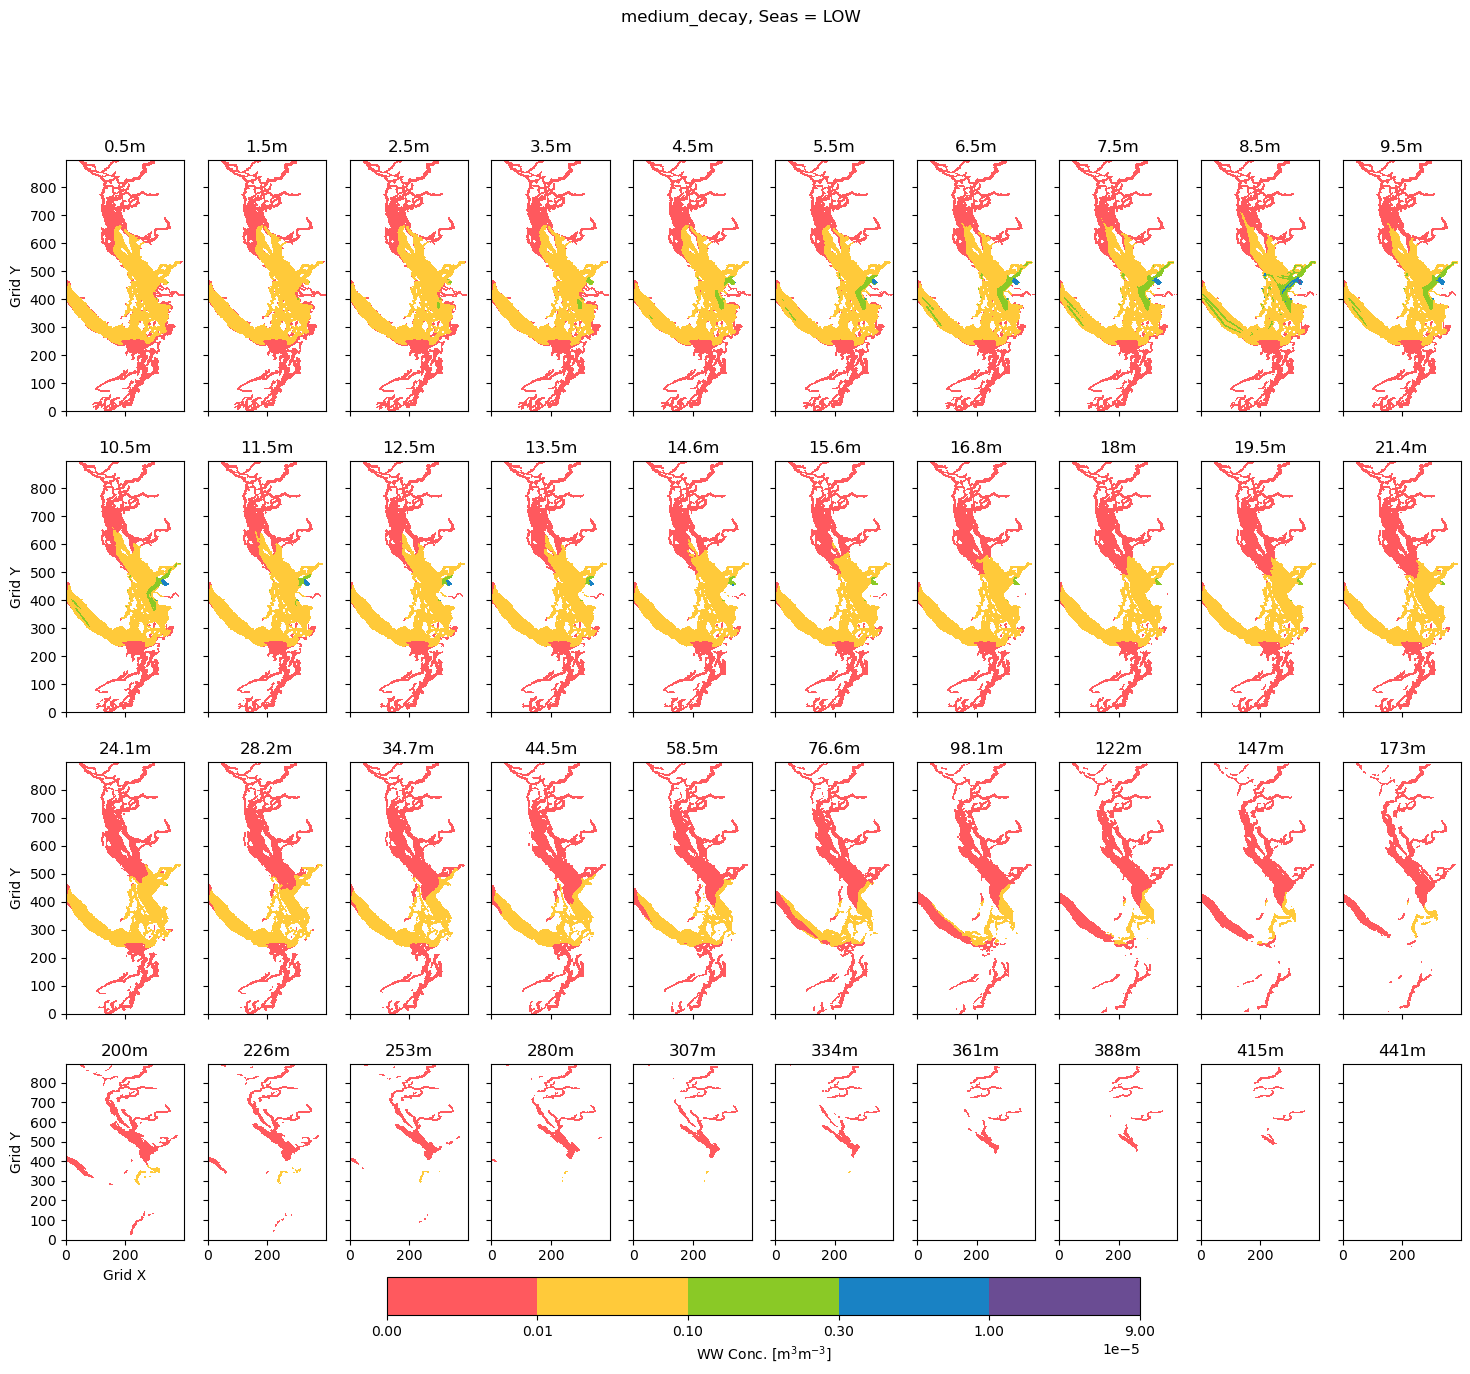

In [37]:
season='LOW'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)
fig.suptitle('Season = LOW')

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

### Fast Decay

In [38]:
decay_var = 'fast_decay'

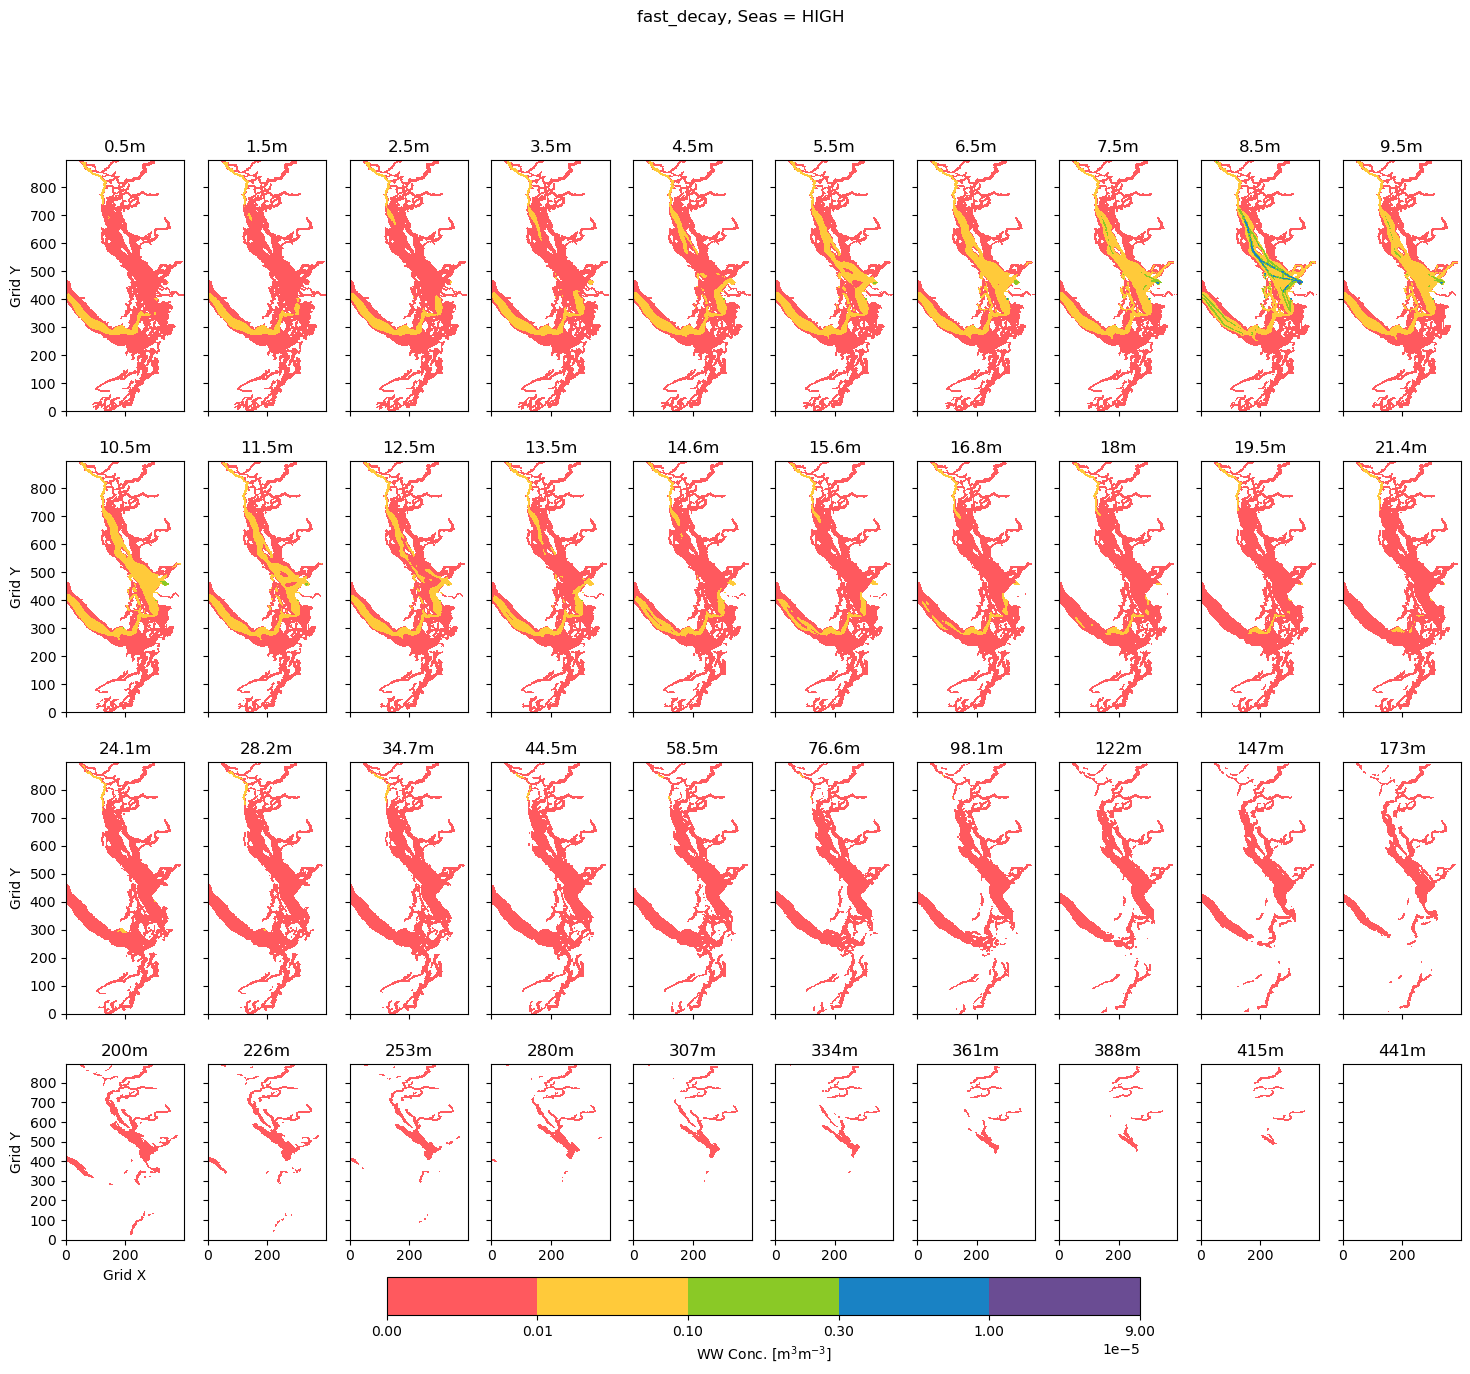

In [39]:
season='HIGH'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

# thresh_arr = create_thresh_arr(ww_seas_mean.sel(season=season)['no_decay'].to_numpy())

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    # vars = plot_thresh_seasonal(thresh_arr, i, season, ax1[y,x], decay_var, False, False, [1,2,3,4,5,6])
    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

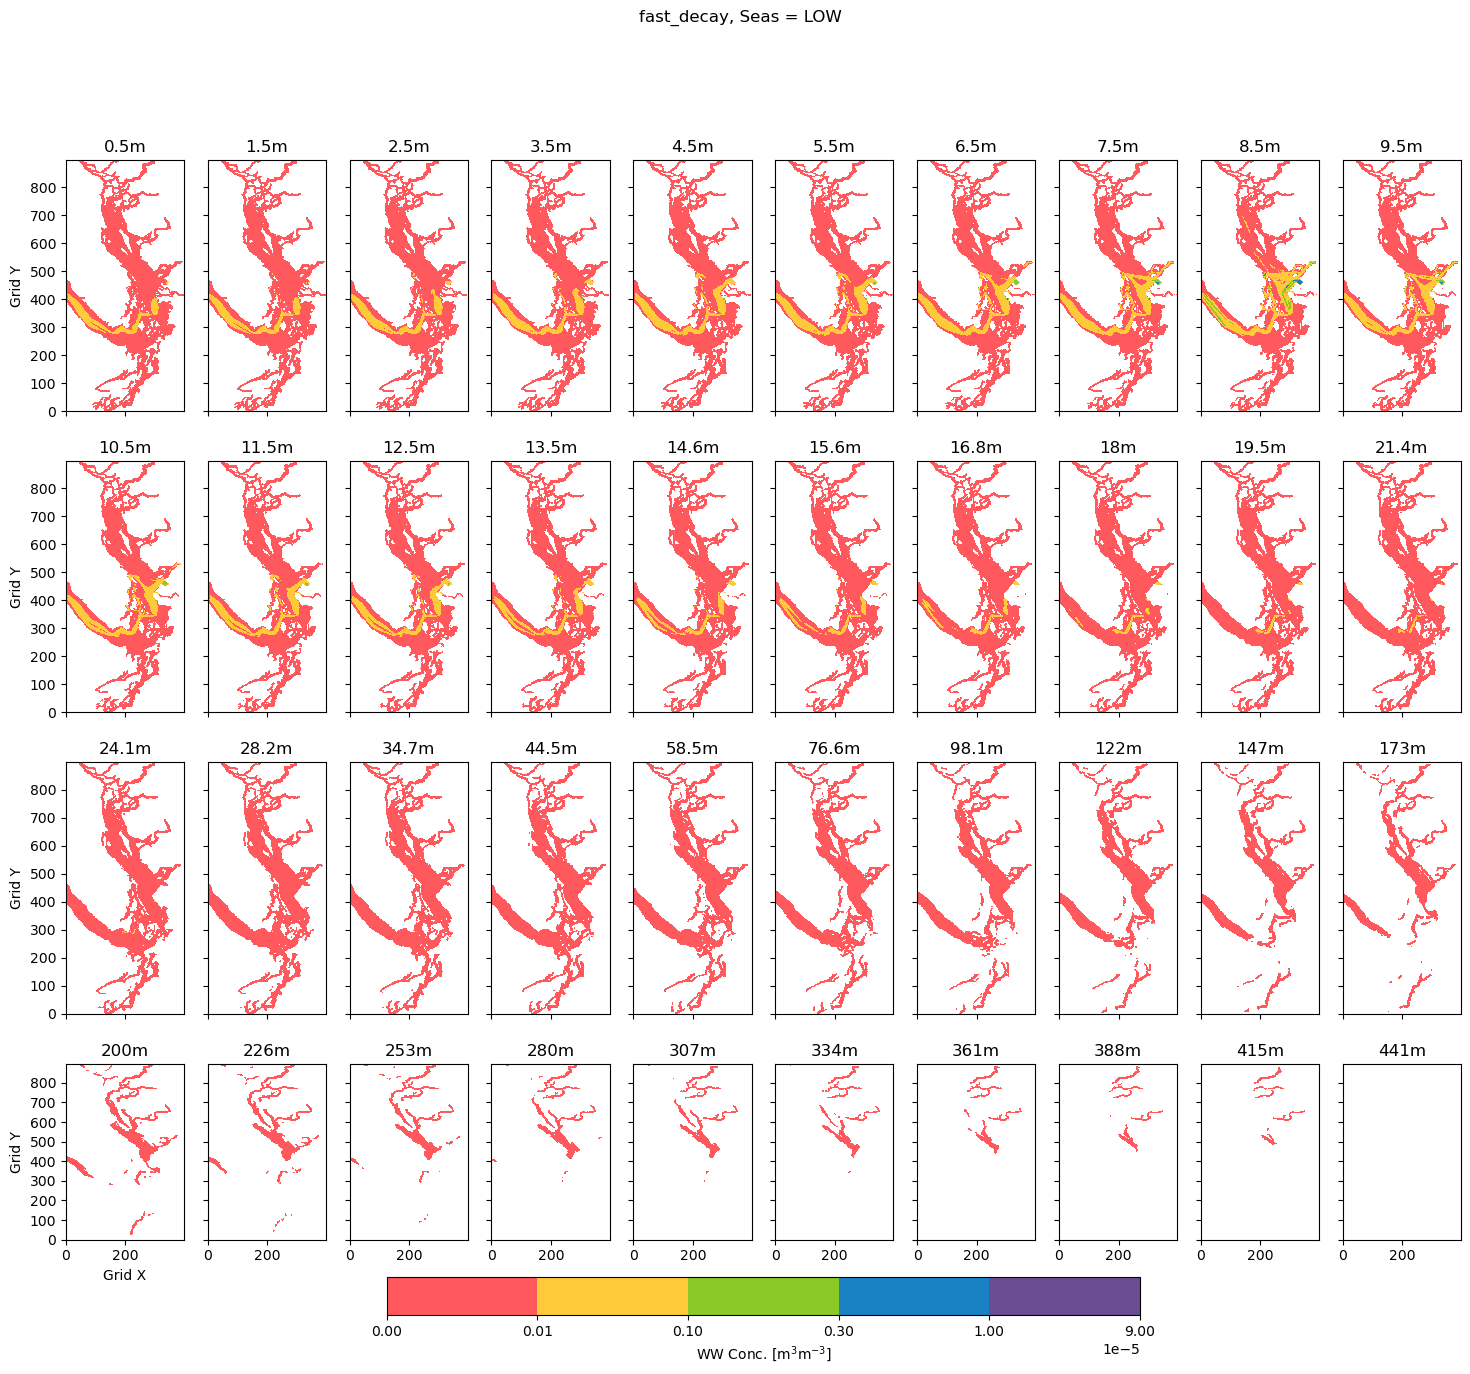

In [40]:
season='LOW'
cmap = mpl.colormaps['viridis']
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig, ax1 = plt.subplots(4,10, figsize = (12*1.5, 10*1.5), sharey=True, sharex=True)
fig.suptitle('Season = LOW')

for i in np.arange(40):

    y = int(np.floor(i/10))
    x = i - y*10

    vars = plot_contours_seasonal(i, season, ax1[y,x], decay_var, False, False, [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high])
    ax1[y,x].set_title('{:.3g}m'.format(ww_out.deptht[i]))

ax1[0,0].set_ylabel('Grid Y')
ax1[1,0].set_ylabel('Grid Y')
ax1[2,0].set_ylabel('Grid Y')
ax1[3,0].set_ylabel('Grid Y')
ax1[3,0].set_xlabel('Grid X')
fig.colorbar(vars[0], ax=ax1[3,:], label=('WW Conc. '+ r'[m$^3$m$^{-3}$]'), location='bottom')

fig.suptitle(decay_var+', Seas = {}'.format(season))
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/contours_seasonal_{}_{}_{}.png'.format(filesave_tag, decay_var, season, filesave_tag))

## Statistics Visualizations

### Functions

In [41]:
def make_barplots(decay_var):
    # ww_high_seas = ww_seas_mean.sel(season='HIGH')[decay_var].stack(flat=['y', 'x']).to_numpy()
    # ww_low_seas = ww_seas_mean.sel(season='LOW')[decay_var].stack(flat=['y', 'x']).to_numpy()

    ww_high_seas = ww_seas_mean.sel(season='HIGH')[decay_var].to_numpy()
    ww_low_seas = ww_seas_mean.sel(season='LOW')[decay_var].to_numpy()
    
    labels = 'Under\nThreshold', 'HC5 Low', 'Impact Urchins', 'HC5', 'Impact Development', 'HC5 High'

    fig, ax1 = plt.subplots(1,2, figsize=(5.5,3.5), sharey=True)
    # ax1[0].bar(['HIGH'], calc_percentages(ww_high_seas)[0:-2], labels=labels[0:-2], colors=custom_colors[0:-1])
    data_high = calc_percentages(ww_high_seas)
    ax1[0].bar(['HIGH'], data_high[0], label=labels[0]+' ({:.3g}%)'.format(data_high[0]*100), color=custom_colors[0], width=1)
    ax1[0].bar(['HIGH'], data_high[1], bottom=data_high[0], label=labels[1]+' ({:.3g}%)'.format(data_high[1]*100), color=custom_colors[1], width=1)
    ax1[0].bar(['HIGH'], data_high[2], bottom=data_high[0]+data_high[1], label=labels[2]+' ({:.3g}%)'.format(data_high[2]*100), color=custom_colors[2], width=1)
    ax1[0].bar(['HIGH'], data_high[3], bottom=data_high[0]+data_high[1]+data_high[2], label=labels[3]+' ({:.3g}%)'.format(data_high[3]*100), color=custom_colors[3], width=1)
    ax1[0].bar(['HIGH'], data_high[4], bottom=data_high[0]+data_high[1]+data_high[2]+data_high[3], label=labels[4]+'\n({:.3g}%)'.format(data_high[4]*100), color=custom_colors[4], width=1)
    ax1[0].legend(bbox_to_anchor=(0.5,-.7), loc='lower center')
    ax1[0].set_ylim(0,1.05)
    print(np.sum(np.array(data_high)))

    data_low = calc_percentages(ww_low_seas)
    ax1[1].bar(['LOW'], data_low[0], label=labels[0]+' ({:.3g}%)'.format(data_low[0]*100), color=custom_colors[0], width=1)
    ax1[1].bar(['LOW'], data_low[1], bottom=data_low[0], label=labels[1]+' ({:.3g}%)'.format(data_low[1]*100), color=custom_colors[1], width=1)
    ax1[1].bar(['LOW'], data_low[2], bottom=data_low[0]+data_low[1], label=labels[2]+' ({:.3g}%)'.format(data_low[2]*100), color=custom_colors[2], width=1)
    ax1[1].bar(['LOW'], data_low[3], bottom=data_low[0]+data_low[1]+data_low[2], label=labels[3]+' ({:.3g}%)'.format(data_low[3]*100), color=custom_colors[3], width=1)
    ax1[1].bar(['LOW'], data_low[4], bottom=data_low[0]+data_low[1]+data_low[2]+data_low[3], label=labels[4]+'\n({:.3g}%)'.format(data_low[4]*100), color=custom_colors[4], width=1)
    ax1[1].set_ylim(0,1.05)
    ax1[1].legend(bbox_to_anchor=(0.5,-.7), loc='lower center')
    print(np.sum(np.array(data_low)))

    fig.suptitle(decay_var)

In [42]:
def plot_all_stats(df, ax1):
    # fig, ax1 = plt.subplots(5,1, figsize=(3, 9), sharex=True)
    ax1[0].plot(df[(df['limit'] == 'Under Threshold') & (df['season'] == 'HIGH')]['decay'], df[(df['limit'] == 'Under Threshold') & (df['season'] == 'HIGH')]['percentage'], 'rs', label='H', alpha=0.5)
    ax1[0].plot(df[(df['limit'] == 'Under Threshold') & (df['season'] == 'LOW')]['decay'], df[(df['limit'] == 'Under Threshold') & (df['season'] == 'LOW')]['percentage'], 'bo', label='L', alpha=0.5)
    ax1[0].grid()
    ax1[0].tick_params(axis='x', labelrotation=90)
    # ax1[0].set_title('Under Threshold')
    ax1[0].set_title('UT')
    ax1[0].set_ylim(ymin=0)

    ax1[1].plot(df[(df['limit'] == 'HC5 Low') & (df['season'] == 'HIGH')]['decay'], df[(df['limit'] == 'HC5 Low') & (df['season'] == 'HIGH')]['percentage'], 'rs', label='H', alpha=0.5)
    ax1[1].plot(df[(df['limit'] == 'HC5 Low') & (df['season'] == 'LOW')]['decay'], df[(df['limit'] == 'HC5 Low') & (df['season'] == 'LOW')]['percentage'], 'bo', label='L', alpha=0.5)
    ax1[1].grid()
    ax1[1].tick_params(axis='x', labelrotation=90)
    # ax1[1].set_title(r'HC5 Low $\geq$ [] $<$ Impact Urchins')
    ax1[1].set_title(r'HC5L$\geq$ [] $<$ IU')
    ax1[1].set_ylim(ymin=0)

    ax1[2].plot(df[(df['limit'] == 'Impact Urchins') & (df['season'] == 'HIGH')]['decay'], df[(df['limit'] == 'Impact Urchins') & (df['season'] == 'HIGH')]['percentage'], 'rs', label='H', alpha=0.5)
    ax1[2].plot(df[(df['limit'] == 'Impact Urchins') & (df['season'] == 'LOW')]['decay'], df[(df['limit'] == 'Impact Urchins') & (df['season'] == 'LOW')]['percentage'], 'bo', label='L', alpha=0.5)
    ax1[2].grid()
    ax1[2].tick_params(axis='x', labelrotation=90)
    # ax1[2].set_title(r'Impact Urchins $\geq$ [] $<$ HC5')
    ax1[2].set_title(r'IU $\geq$ [] $<$ HC5')
    ax1[2].set_ylabel('% of Volume')
    ax1[2].set_ylim(ymin=0)

    ax1[3].plot(df[(df['limit'] == 'HC5') & (df['season'] == 'HIGH')]['decay'], df[(df['limit'] == 'HC5') & (df['season'] == 'HIGH')]['percentage'], 'rs', label='H', alpha=0.5)
    ax1[3].plot(df[(df['limit'] == 'HC5') & (df['season'] == 'LOW')]['decay'], df[(df['limit'] == 'HC5') & (df['season'] == 'LOW')]['percentage'], 'bo', label='L', alpha=0.5)
    ax1[3].grid()
    ax1[3].tick_params(axis='x', labelrotation=90)
    # ax1[3].set_title(r'HC5 $\geq$ [] $<$ Impact Development')
    ax1[3].set_title(r'HC5 $\geq$ [] $<$ ID')
    ax1[3].set_ylim(ymin=0)

    ax1[4].plot(df[(df['limit'] == 'Impact Development') & (df['season'] == 'HIGH')]['decay'], df[(df['limit'] == 'Impact Development') & (df['season'] == 'HIGH')]['percentage'], 'rs', label='HIGH', alpha=0.5)
    ax1[4].plot(df[(df['limit'] == 'Impact Development') & (df['season'] == 'LOW')]['decay'], df[(df['limit'] == 'Impact Development') & (df['season'] == 'LOW')]['percentage'], 'bo', label='LOW', alpha=0.5)
    ax1[4].grid()
    ax1[4].tick_params(axis='x', labelrotation=90)
    # ax1[4].set_title(r'Impact Development $\geq$ [] $<$ HC5 High')
    ax1[4].set_title(r'ID $\geq$ [] $<$ HC5H')
    ax1[4].set_ylim(ymin=0)

    ax1[4].legend(bbox_to_anchor=(1.1,0.1), loc='lower center')

    fig.tight_layout(pad=1.2)

In [43]:
def make_boxplots(decay_var, season):
    ww_sel_seas = ww_seas_mean.sel(season=season)[decay_var].stack(flat=['y', 'x']).to_numpy()
    # ww_low_seas = ww_seas_mean.sel(season='LOW')[decay_var].stack(flat=['y', 'x']).to_numpy()

    dmax = np.nanmax(ww_sel_seas, axis=1)
    dmin = np.nanmin(ww_sel_seas, axis=1)
    dquant = np.nanquantile(ww_sel_seas, [0.25, 0.5, 0.75], axis=1)

    iqr = dquant[2,:] - dquant[0,:]
    lower_bound = dquant[0,:] - 1.5 * iqr
    lower_bound[lower_bound < 0] = 0
    upper_bound = dquant[2,:] + 1.5 * iqr

    outliers = ww_sel_seas[ww_sel_seas > upper_bound.reshape(-1, 1)]
    ww_sel_seas_max = np.nanmax(ww_sel_seas)

    fig, ax = plt.subplots(1,40, figsize=(11, 8.5), sharey=True)  #TODO: change the boxes and whiskers to better fit my use case?

    for i in np.arange(40):
        ub = upper_bound[i]
        ts = ww_sel_seas[i,:]
        outliers = ts[ts > ub]

        boxplot_stats = [
            {
                'label': '{:.3g}'.format(float(ww_out.deptht[i])),
                'whislo': lower_bound[i],    # Bottom whisker (min non-outlier)
                'q1': dquant[0,i],      # First quartile (25th percentile)
                'med': dquant[1,i],     # Median (50th percentile)
                'q3': dquant[2,i],      # Third quartile (75th percentile)
                'whishi': upper_bound[i],    # Top whisker (max non-outlier)
                'fliers': outliers # Outliers
            }
        ]

        ax[i].bxp(boxplot_stats, showfliers=True, patch_artist=True, boxprops={'facecolor': 'lightblue'}, vert=True)

        ax[i].add_patch(plt.Rectangle((0.5, 0), 1, HC5_high, facecolor=custom_colors[4]))
        ax[i].add_patch(plt.Rectangle((0.5, 0), 1, impact_devel, facecolor=custom_colors[3]))
        ax[i].add_patch(plt.Rectangle((0.5, 0), 1, HC5, facecolor=custom_colors[2]))
        ax[i].add_patch(plt.Rectangle((0.5, 0), 1, impact_urchins, facecolor=custom_colors[1]))
        ax[i].add_patch(plt.Rectangle((0.5, 0), 1, HC5_low, facecolor=custom_colors[0]))

        ax[i].set_ylim([-.25e-6, ww_sel_seas_max*0.85])
        ax[i].tick_params(axis='x', labelrotation=90)
        
    ax[0].set_ylabel('WW Conc. '+ r'[m$^3$m$^{-3}$]')
    ax[19].set_xlabel('Depth [m]')

    # [0, HC5_low, impact_urchins, HC5, impact_devel, HC5_high]

    fig.suptitle(decay_var+', Seas = {}'.format(season))
    plt.show()



### Bar Plots

In [44]:
labels = ['Under Threshold', 'HC5 Low', 'Impact Urchins', 'HC5', 'Impact Development', 'HC5 High']
column_names = ['limit', 'season', 'decay', 'percentage']
data1 = np.array([labels, ['HIGH']*6, ['no_decay']*6, calc_percentages(ww_seas_mean.sel(season='HIGH')['no_decay'].to_numpy())])
perct_df = pd.DataFrame(np.array(data1).T, columns=column_names)
data2 = np.array([labels, ['LOW']*6, ['no_decay']*6, calc_percentages(ww_seas_mean.sel(season='LOW')['no_decay'].to_numpy())])
perct_df = pd.concat([perct_df, pd.DataFrame(np.array(data2).T, columns=column_names)])

data = np.array([labels, ['HIGH']*6, ['slow_decay']*6, calc_percentages(ww_seas_mean.sel(season='HIGH')['slow_decay'].to_numpy())])
perct_df = pd.concat([perct_df, pd.DataFrame(np.array(data).T, columns=column_names)])
data = np.array([labels, ['LOW']*6, ['slow_decay']*6, calc_percentages(ww_seas_mean.sel(season='LOW')['slow_decay'].to_numpy())])
perct_df = pd.concat([perct_df, pd.DataFrame(np.array(data).T, columns=column_names)])

data = np.array([labels, ['HIGH']*6, ['medium_decay']*6, calc_percentages(ww_seas_mean.sel(season='HIGH')['medium_decay'].to_numpy())])
perct_df = pd.concat([perct_df, pd.DataFrame(np.array(data).T, columns=column_names)])
data = np.array([labels, ['LOW']*6, ['medium_decay']*6, calc_percentages(ww_seas_mean.sel(season='LOW')['medium_decay'].to_numpy())])
perct_df = pd.concat([perct_df, pd.DataFrame(np.array(data).T, columns=column_names)])

data = np.array([labels, ['HIGH']*6, ['fast_decay']*6, calc_percentages(ww_seas_mean.sel(season='HIGH')['fast_decay'].to_numpy())])
perct_df = pd.concat([perct_df, pd.DataFrame(np.array(data).T, columns=column_names)])
data = np.array([labels, ['LOW']*6, ['fast_decay']*6, calc_percentages(ww_seas_mean.sel(season='LOW')['fast_decay'].to_numpy())])
perct_df = pd.concat([perct_df, pd.DataFrame(np.array(data).T, columns=column_names)])
perct_df = perct_df.reset_index()
perct_df['percentage'] = perct_df['percentage'].astype('float')*100
perct_df = perct_df[['limit', 'season', 'decay', 'percentage']]

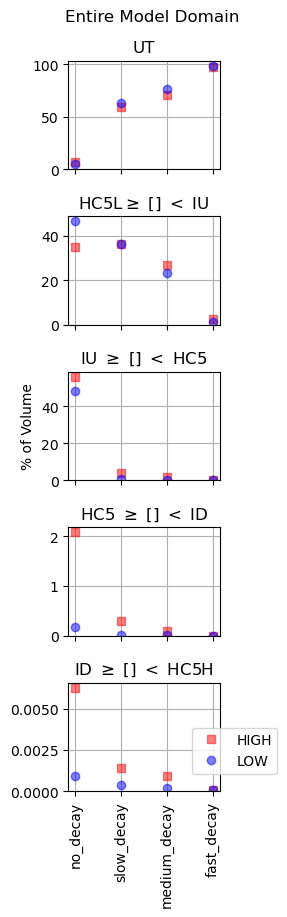

In [45]:
fig, ax1 = plt.subplots(5,1, figsize=(3, 9), sharex=True)
plot_all_stats(perct_df, ax1)
plt.suptitle('Entire Model Domain\n', va='bottom')
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/stats_summary_{}_{}.png'.format(filesave_tag, 'entire', filesave_tag))

1.0000000000000007
1.0000000000000002


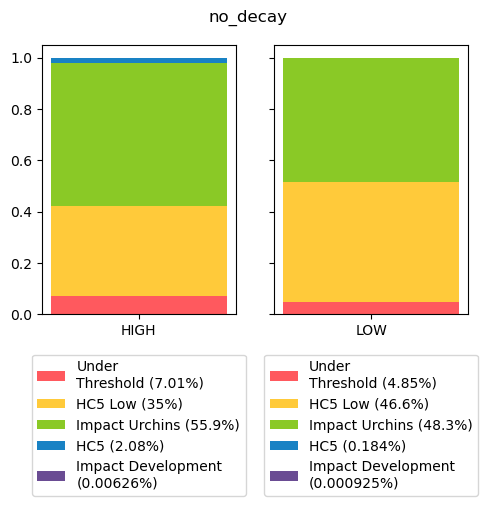

In [46]:
make_barplots('no_decay')
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/barplot_{}_{}.png'.format(filesave_tag, 'no_decay', filesave_tag))

1.0000000000000002
1.0


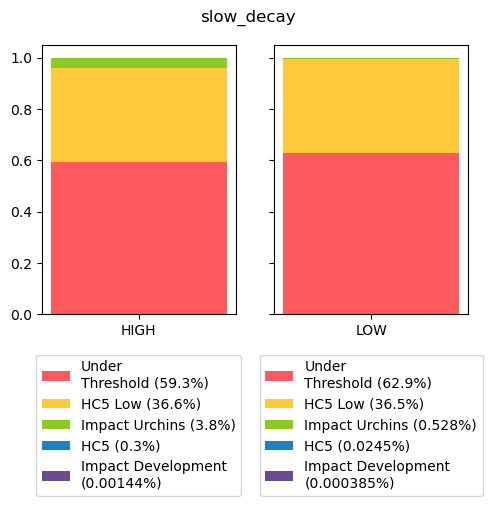

In [47]:
make_barplots('slow_decay')
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/barplot_{}_{}.png'.format(filesave_tag, 'slow_decay', filesave_tag))

1.0000000000000007
1.0000000000000002


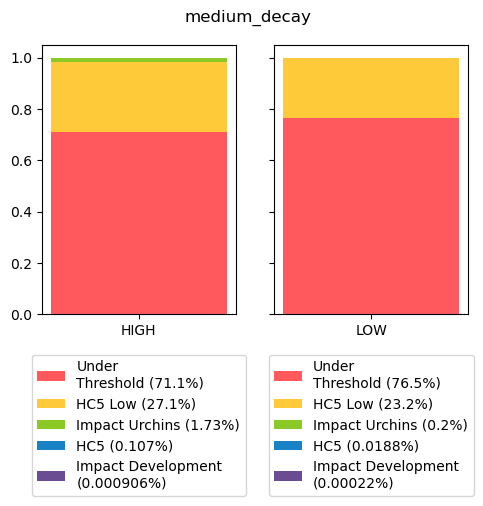

In [48]:
make_barplots('medium_decay')
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/barplot_{}_{}.png'.format(filesave_tag, 'medium_decay', filesave_tag))

1.0000000000000004
1.0000000000000004


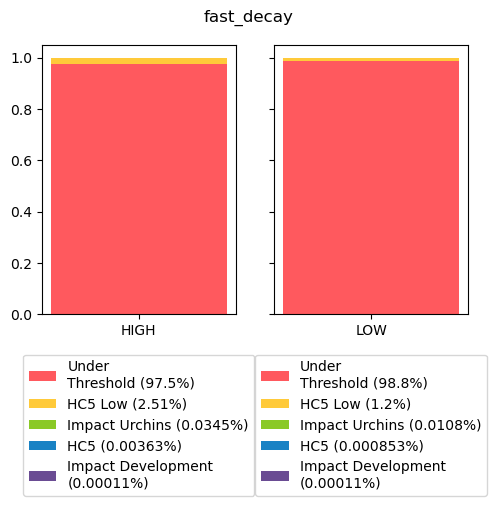

In [49]:
make_barplots('fast_decay')
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/barplot_{}_{}.png'.format(filesave_tag, 'fast_decay', filesave_tag))

### Box Plots

In [50]:
# make_boxplots('no_decay', 'HIGH')
# make_boxplots('no_decay', 'LOW')

In [51]:
# make_boxplots('slow_decay', 'HIGH')
# make_boxplots('slow_decay', 'LOW')

In [52]:
# make_boxplots('medium_decay', 'HIGH')
# make_boxplots('medium_decay', 'LOW')

In [53]:
# make_boxplots('fast_decay', 'HIGH')
# make_boxplots('fast_decay', 'LOW')

## SRKW Habitat

In [54]:
crit_hab = gpd.read_file('crit_hab.gdb', layer='DFO_SARA_CH_EDH_EN')
orca = crit_hab['COMMON_E'] == 'Killer Whale'
crit_hab[orca]

/home/cdonaldson/conda_envs/analysis-2/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


,COMMON_E,POP_E,COMMON_F,POP_F,SCIENTIFIC,TAXON_E,ECO_TYPE_E,Waterbody,SARASTAT_E,CHSTATUS_E,COMMENT_E,LEAD_REG_E,SUP_REG_E,PROFILE_E,Area_Km2,Shape_Length,Shape_Area,geometry
864,Killer Whale,Northeast Pacific Northern Resident,Épaulard,résidente du nord du Pacifique Nord-Est,Orcinus orca,Mammals,Marine,Pacific Ocean/Océan Pacifique,Threatened,Final,None,Pacific,None,https://species-registry.canada.ca/index-en.ht...,7319.681360,1.924220e+06,1.774748e+10,"MULTIPOLYGON (((-13985503.47 6274700.411, -139..."
865,Killer Whale,Northeast Pacific Southern Resident,Épaulard,résidente du sud du Pacifique Nord-Est,Orcinus orca,Mammals,Marine,Pacific Ocean/Océan Pacifique,Endangered,Final,None,Pacific,None,https://species-registry.canada.ca/index-en.ht...,7496.738906,1.913499e+06,1.712860e+10,"MULTIPOLYGON (((-13985503.47 6274700.411, -139..."


In [55]:
poly1 = crit_hab.iloc[864]['geometry']
poly2 = crit_hab.iloc[865]['geometry']

In [56]:
import shapely
from shapely.ops import transform
import pyproj

# Define projections
project = pyproj.Transformer.from_crs(
    "EPSG:3857",  # source (likely)
    "EPSG:4326",  # target (lat/lon)
    always_xy=True
).transform

# Reproject polygon
poly1_ll = transform(project, poly1)
poly2_ll = transform(project, poly2)

In [57]:
mask1 = shapely.contains(poly1_ll, shapely.points(ww_out.nav_lon, ww_out.nav_lat))
mask2 = shapely.contains(poly2_ll, shapely.points(ww_out.nav_lon, ww_out.nav_lat))
crit_mask = np.logical_or(mask1, mask2)
crit_mask_3d = np.tile(crit_mask, (40, 1, 1))

In [58]:
# labels = ['Under Threshold', 'HC5 Low', 'Impact Urchins', 'HC5', 'Impact Development', 'HC5 High']
# column_names = ['limit', 'season', 'decay', 'percentage']
data1 = np.array([labels, ['HIGH']*6, ['no_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='HIGH')['no_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.DataFrame(np.array(data1).T, columns=column_names)
data2 = np.array([labels, ['LOW']*6, ['no_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='LOW')['no_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.concat([perct_df_crit, pd.DataFrame(np.array(data2).T, columns=column_names)])

data = np.array([labels, ['HIGH']*6, ['slow_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='HIGH')['slow_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.concat([perct_df_crit, pd.DataFrame(np.array(data).T, columns=column_names)])
data = np.array([labels, ['LOW']*6, ['slow_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='LOW')['slow_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.concat([perct_df_crit, pd.DataFrame(np.array(data).T, columns=column_names)])

data = np.array([labels, ['HIGH']*6, ['medium_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='HIGH')['medium_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.concat([perct_df_crit, pd.DataFrame(np.array(data).T, columns=column_names)])
data = np.array([labels, ['LOW']*6, ['medium_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='LOW')['medium_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.concat([perct_df_crit, pd.DataFrame(np.array(data).T, columns=column_names)])

data = np.array([labels, ['HIGH']*6, ['fast_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='HIGH')['fast_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.concat([perct_df_crit, pd.DataFrame(np.array(data).T, columns=column_names)])
data = np.array([labels, ['LOW']*6, ['fast_decay']*6, calc_perc_crit(create_thresh_arr(ww_seas_mean.sel(season='LOW')['fast_decay'].to_numpy()), ~crit_mask_3d)])
perct_df_crit = pd.concat([perct_df_crit, pd.DataFrame(np.array(data).T, columns=column_names)])
perct_df_crit = perct_df_crit.reset_index()
perct_df_crit['percentage'] = perct_df_crit['percentage'].astype('float')*100
perct_df_crit = perct_df_crit[['limit', 'season', 'decay', 'percentage']]

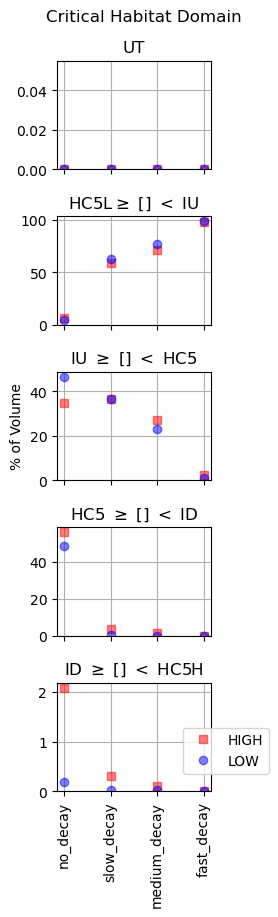

In [59]:
fig, ax1 = plt.subplots(5,1, figsize=(3, 9), sharex=True)
plot_all_stats(perct_df_crit, ax1)
plt.suptitle('Critical Habitat Domain\n', va='bottom')
plt.savefig('/ocean/cdonaldson/MOAD/analysis-cassidy/notebooks/dfo-cd/figures/{}/stats_summary_{}_{}.png'.format(filesave_tag, 'crit', filesave_tag))

## Plot Input Data

In [60]:
matter_color = mcolors.to_hex(cm.matter(0.75))
haline_color = mcolors.to_hex(cm.haline(0.15))
thermal_color = mcolors.to_hex(cm.thermal(0.80))

In [61]:
ww_in_sum = ww_in.washwater.sum(dim='time')

In [62]:
washwater_flat = ww_in.washwater.values.flatten()
temp_out_flat = ww_in.temp_out.values.flatten()
sal_out_flat = ww_in.sal_out.values.flatten()

washwater_flat = washwater_flat[~np.isnan(washwater_flat)]
temp_out_flat = temp_out_flat[~np.isnan(temp_out_flat)]
sal_out_flat = sal_out_flat[~np.isnan(sal_out_flat)]

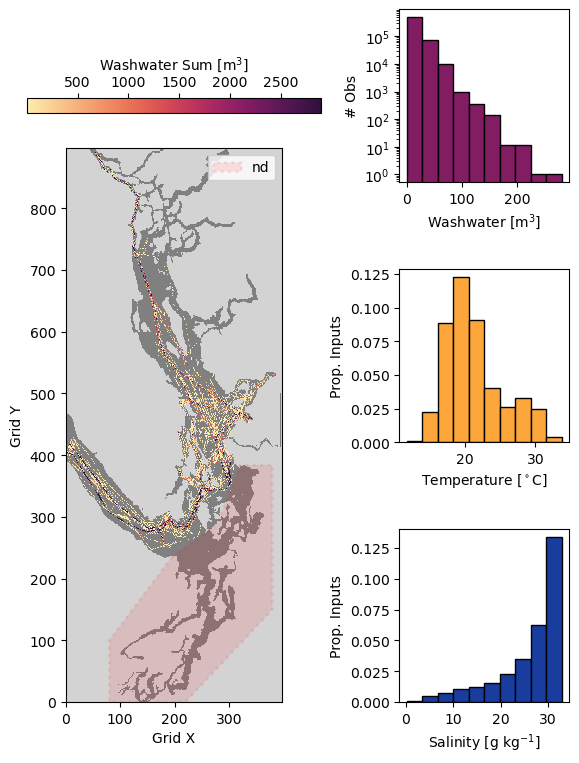

In [63]:
cmap = cm.matter
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig = plt.figure(figsize = (7, 9))
grid = plt.GridSpec(3,5, wspace=1.7, hspace=0.5)
ax1 = plt.subplot(grid[0:,0:3])
ax2 = plt.subplot(grid[0,3:])
ax3 = plt.subplot(grid[1,3:])
ax4 = plt.subplot(grid[2,3:])

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax1.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
cb = fig.colorbar(colours, ax=ax1, label=r'Washwater Sum [m$^3$]', location='top')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='nd')
ax1.add_patch(patch)
ax1.set_ylabel('Grid Y')
ax1.set_xlabel('Grid X')
viz_tools.set_aspect(ax1);

ax2.hist(washwater_flat, 10, density=False, log=True, color=matter_color, edgecolor='k')
ax2.set_xlabel(r'Washwater [m$^3$]')
ax2.set_ylabel('# Obs')

ax3.hist(temp_out_flat, 10, density=True, log=False, color=thermal_color, edgecolor='k')
ax3.set_xlabel(r'Temperature [$^\circ$C]')
ax3.set_ylabel('Prop. Inputs')

ax4.hist(sal_out_flat, 10, density=True, log=False, color=haline_color, edgecolor='k')
ax4.set_xlabel(r'Salinity [g kg$^{-1}$]')
ax4.set_ylabel('Prop. Inputs')

ax1.legend()

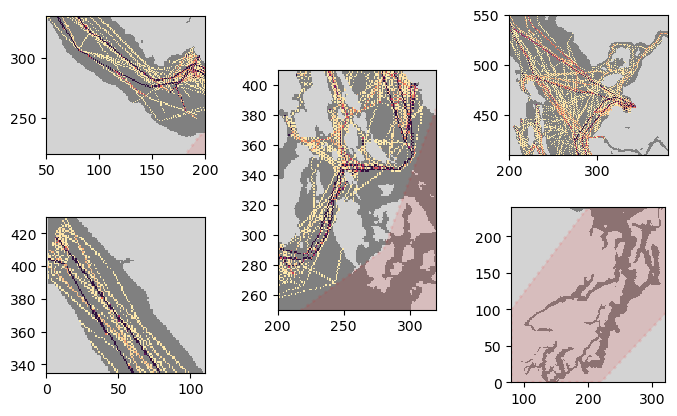

In [64]:
cmap = cm.matter
cmap.set_bad('lightgray')
cmap.set_under('gray')

fig = plt.figure(figsize = (11, 5))
grid = plt.GridSpec(4,8, wspace=1.7, hspace=0.5)
ax1 = plt.subplot(grid[0:2,0:2])
ax2 = plt.subplot(grid[2:4,0:2])
ax3 = plt.subplot(grid[0:4:,2:4])
ax4 = plt.subplot(grid[0:2:,4:6])
ax5 = plt.subplot(grid[2:4:,4:6])

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax1.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax1, label=r'Washwater Sum [m$^3$]', location='left')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax1.add_patch(patch)
ax1.set_xlim([50,200])
ax1.set_ylim([220,335])
viz_tools.set_aspect(ax1);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax2.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax2, label=r'Washwater Sum [m$^3$]', location='left')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax2.add_patch(patch)
ax2.set_xlim([0,110])
ax2.set_ylim([335,430])
viz_tools.set_aspect(ax2);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax3.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax3, label=r'Washwater Sum [m$^3$]')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax3.add_patch(patch)
ax3.set_xlim([200,320])
ax3.set_ylim([250,410])
viz_tools.set_aspect(ax3);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax4.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax4, label=r'Washwater Sum [m$^3$]')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax4.add_patch(patch)
ax4.set_xlim([200,380])
ax4.set_ylim([410,550])
viz_tools.set_aspect(ax4);

washwater = np.ma.masked_array(np.nan_to_num(ww_in_sum), mask=tmask[8])
colours = ax5.pcolormesh(washwater, cmap=cmap, vmax=2900, vmin=0.5)
# cb = fig.colorbar(colours, ax=ax5, label=r'Washwater Sum [m$^3$]')
US_exclusion = shapely.geometry.Polygon([(195, 235), (280, 290), (320, 384), (380, 384), (380, 150), (220, 0), (80, 0), (80, 100)])
patch = MatplotlibPolygon(US_exclusion.exterior.coords, closed=True, facecolor='red', alpha=0.1, edgecolor='red', linewidth=2, linestyle='dotted', label='no ww\ndata')
ax5.add_patch(patch)
ax5.set_xlim([80,320])
ax5.set_ylim([0,240])
viz_tools.set_aspect(ax5);